In [10]:
import os
import sys
import gtfparse
from matplotlib.backend_bases import NonGuiException
import numpy as np
import pandas as pd
from pathlib import Path
import logging
import json
import muon as mu
from sklearn.metrics import roc_auc_score

import torch
import argparse

PROJECT_DIR = Path("/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/TETHER")
sys.path.append(str(PROJECT_DIR))

DATA_DIR = PROJECT_DIR.parent / "data"
CHKPT_DIR = PROJECT_DIR / "checkpoints"

import utils
from utils import prepare_tftg_lookup_tables, build_tftg_inputs

logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")

def _format_chroms(chroms: list[str]) -> str:
    """Render a chromosome list for logging.

    Only for log messages -- the splits themselves are made with isin() on the full list.
    min()/max() would compare these as strings, where "9" > "15", so ["1".."15"] printed
    as "1-15" came out as "1-9". Numeric labels are ordered numerically and collapsed to
    a range only when they are actually contiguous.
    """
    numeric = sorted((c for c in chroms if str(c).isdigit()), key=int)
    other = sorted(str(c) for c in chroms if not str(c).isdigit())

    parts = []
    if numeric:
        contiguous = int(numeric[-1]) - int(numeric[0]) == len(numeric) - 1
        parts.append(f"{numeric[0]}-{numeric[-1]}" if contiguous and len(numeric) > 1
                     else ", ".join(numeric))
    parts.extend(other)
    return ", ".join(parts)


def split_genes_by_chromosome(
    gene_reference_file: Path,
    train_chroms: list[str] = None,
    val_chroms: list[str] = None,
    test_chroms: list[str] = None
    ):
    logging.info(f"Splitting genes into train/val/test based on chromosome:")
    gene_ref_df = gtfparse.read_gtf(gene_reference_file, result_type="pandas")

    gene_chrom: pd.DataFrame = gene_ref_df[["seqname", "gene_name"]].rename(
        columns={"seqname": "chrom", "gene_name": "TG"}
    )
    
    gene_chrom["chrom"] = gene_chrom["chrom"].astype(str).str.replace("^chr", "", regex=True)
    gene_chrom["TG"] = gene_chrom["TG"].str.upper()
    
    train_genes = gene_chrom[gene_chrom["chrom"].isin(train_chroms)][
        "TG"
    ].unique()
    logging.info(f"  - Train set: {len(train_genes):,} genes (chroms {_format_chroms(train_chroms)})")

    val_genes = gene_chrom[gene_chrom["chrom"].isin(val_chroms)][
        "TG"
    ].unique()
    logging.info(f"  - Validation set: {len(val_genes):,} genes (chroms {_format_chroms(val_chroms)})")

    test_genes = gene_chrom[gene_chrom["chrom"].isin(test_chroms)]["TG"].unique()
    logging.info(f"  - Test set: {len(test_genes):,} genes (chroms {_format_chroms(test_chroms)})")

    return train_genes, val_genes, test_genes


def create_axis_matched_edges(edge_df, tf_col="Source", item_col="Target",
                              axis="tg", true_false_ratio=1.0, seed=123):
    """Negatives drawn inside each level of one axis, matching that marginal exactly.

    axis="tg": for each target gene, negatives are TFs not linked to it. Every
        TG-level feature -- peak bag, TSS distance, target expression -- then carries
        zero information about the label.
    axis="tf": the mirror, for each TF.

    It cannot do both. Matching one marginal SHARPENS the imbalance on the other: a
    TF linked to 87% of genes is almost never drawable as a negative under axis="tg",
    so its per-TF label rate goes to 0.98. Use create_degree_matched_edges when both
    axes must be balanced.
    """
    rng = np.random.default_rng(seed)

    df = (edge_df[[tf_col, item_col]].dropna().astype(str)
          .drop_duplicates().reset_index(drop=True))

    group_col, other_col = (item_col, tf_col) if axis == "tg" else (tf_col, item_col)
    as_pair = (lambda k, o: (o, k)) if axis == "tg" else (lambda k, o: (k, o))

    all_others = np.array(sorted(df[other_col].unique()))
    true_edges, false_edges, short = set(), set(), 0

    for key, group in df.groupby(group_col):
        positives = set(group[other_col])
        true_edges |= {as_pair(key, o) for o in positives}

        available = all_others[~np.isin(all_others, list(positives))]
        wanted = round(len(positives) * true_false_ratio)
        n_drawn = min(wanted, len(available))
        short += n_drawn < wanted
        if n_drawn:
            drawn = rng.choice(available, size=n_drawn, replace=False)
            false_edges |= {as_pair(key, o) for o in drawn}

    logging.info(
        f"{axis.upper()}-matched: {len(true_edges):,} positive, {len(false_edges):,} "
        f"negative (ratio {len(false_edges) / max(len(true_edges), 1):.2f}, "
        f"requested {true_false_ratio}); {short:,} / {df[group_col].nunique():,} "
        f"levels could not reach it"
    )
    return true_edges, false_edges


def create_balanced_edges(edge_df, *, balance_tf, balance_tg,
                          tf_col="Source", item_col="Target",
                          pct_true_edges=1.0, true_false_ratio=1.0, seed=123):
    """Dispatch to the sampler matching the requested balance.

    both  -> rectangles: exact on TF and TG, at the cost of using a subset of the GT
    tg    -> per-TG negatives; TF marginal is left skewed and usually worse
    tf    -> per-TF negatives; TG marginal is left skewed
    none  -> uniform over the TF x TG box; both identities predict the label
    """
    if balance_tf and balance_tg:
        return create_degree_matched_edges(edge_df, tf_col, item_col, seed=seed)
    if balance_tf or balance_tg:
        return create_axis_matched_edges(
            edge_df, tf_col, item_col,
            axis="tf" if balance_tf else "tg",
            true_false_ratio=true_false_ratio, seed=seed,
        )
    return create_true_false_edges_from_full_universe(
        edge_df, tf_col, item_col,
        pct_true_edges=pct_true_edges,
        true_false_ratio=true_false_ratio, seed=seed,
    )


def create_degree_matched_edges(edge_df, tf_col="Source", item_col="Target",
                                seed=123, max_partners=32):
    """Negatives that preserve BOTH the TF out-degree and the TG in-degree.

    Pairs of GT edges (t1,g1),(t2,g2) whose crossed pairs (t1,g2),(t2,g1) are both
    non-edges contribute two positives and two negatives. Each of t1, t2, g1, g2 then
    gains exactly one positive and one negative, so per-TF and per-TG label rates are
    0.5 by construction and neither identity predicts the label.

    A rectangle is all-or-nothing. Accepting one whose positives were already used
    would add two negatives and fewer than two positives, which is what breaks the
    balance -- so every one of the four pairs must be unused.

    Each GT edge is consumed at most once, so this walks a shuffled edge list and
    looks for a partner, rather than sampling random pairs and rejecting: as the
    unused pool shrinks, random pairing almost always collides.
    """
    rng = np.random.default_rng(seed)

    df = (edge_df[[tf_col, item_col]].dropna().astype(str)
          .drop_duplicates().reset_index(drop=True))
    gt = set(zip(df[tf_col], df[item_col]))

    pool = list(gt)
    rng.shuffle(pool)
    available = set(pool)

    true_edges, false_edges = set(), set()

    for edge in pool:
        if edge not in available:
            continue
        t1, g1 = edge

        partners = rng.choice(len(pool), size=min(max_partners, len(pool)), replace=False)
        for p in partners:
            other = pool[p]
            if other not in available or other == edge:
                continue
            t2, g2 = other
            if t1 == t2 or g1 == g2:
                continue
            if (t1, g2) in gt or (t2, g1) in gt:
                continue
            if (t1, g2) in false_edges or (t2, g1) in false_edges:
                continue

            true_edges |= {edge, other}
            false_edges |= {(t1, g2), (t2, g1)}
            available.discard(edge)
            available.discard(other)
            break

    logging.info(
        f"Degree-matched sampling: {len(true_edges):,} positive, {len(false_edges):,} "
        f"negative ({len(true_edges) / max(len(gt), 1):.1%} of the GT used)"
    )
    return true_edges, false_edges


def create_train_val_test_splits(
    tf_tg_labeled_df: pd.DataFrame,
    train_genes: np.ndarray,
    val_genes: np.ndarray,
    test_genes: np.ndarray,
):
    train_genes_set = set(train_genes)
    val_genes_set = set(val_genes)
    test_genes_set = set(test_genes)

    # Subset the ground truth to create train/val/test splits based on the target gene chromosome splits
    gt_train_df = tf_tg_labeled_df[tf_tg_labeled_df["tg_id"].isin(train_genes_set)].copy()
    gt_val_df = tf_tg_labeled_df[tf_tg_labeled_df["tg_id"].isin(val_genes_set)].copy()
    gt_test_df = tf_tg_labeled_df[tf_tg_labeled_df["tg_id"].isin(test_genes_set)].copy()
    
    if len(gt_train_df) == 0:
        logging.warning("No training interactions found for the selected train genes.")
        logging.info(f"Dataset genes: {list(train_genes_set)[:5]}")
        logging.info(f"Ground truth target genes: {tf_tg_labeled_df['tg_id'].unique()[:5]}")

    return gt_train_df, gt_val_df, gt_test_df


def create_true_false_edges_from_full_universe(
    edge_df: pd.DataFrame,
    tf_col: str = "Source",
    item_col: str = "Target",
    pct_true_edges: float | None = 1.0,
    true_false_ratio: float = 1.0,
    seed: int = 123,
):
    df_all = edge_df[[tf_col, item_col]].copy()

    df_all = df_all.dropna(subset=[tf_col, item_col])

    df_all[tf_col] = df_all[tf_col].astype(str)
    df_all[item_col] = df_all[item_col].astype(str)

    df_all = df_all.drop_duplicates([tf_col, item_col]).reset_index(drop=True)

    if df_all.empty:
        raise ValueError(
            f"No edges remain after filtering by tf_names using columns "
            f"{tf_col!r} and {item_col!r}."
        )

    candidate_tfs = sorted(df_all[tf_col].unique())
    candidate_items = sorted(df_all[item_col].unique())

    gt_pairs = set(zip(df_all[tf_col], df_all[item_col]))

    full_universe = (
        pd.MultiIndex
        .from_product([candidate_tfs, candidate_items], names=[tf_col, item_col])
        .to_frame(index=False)
    )

    full_universe["_pair"] = list(zip(full_universe[tf_col], full_universe[item_col]))
    full_universe["_in_gt"] = full_universe["_pair"].isin(gt_pairs)

    true_df = full_universe[full_universe["_in_gt"]].copy()
    false_df = full_universe[~full_universe["_in_gt"]].copy()

    if pct_true_edges is not None:
        if not (0 < pct_true_edges <= 1):
            raise ValueError("pct_true_edges must be in (0, 1] or None.")

        true_df = true_df.sample(frac=pct_true_edges, random_state=seed)

    n_false = round(len(true_df) * true_false_ratio)

    if n_false > len(false_df):
        logging.warning(
            f"Requested {n_false:,} false edges, but only {len(false_df):,} are available. "
            "Using all available false edges."
        )
        n_false = len(false_df)

    false_df = false_df.sample(n=n_false, random_state=seed)

    true_edges = set(zip(true_df[tf_col], true_df[item_col]))
    false_edges = set(zip(false_df[tf_col], false_df[item_col]))

    return true_edges, false_edges


def create_labeled_tf_tg_dataset(
    true_interactions: set[tuple[str, str]],
    false_interactions: set[tuple[str, str]],
    tf_name_to_idx: dict[str, int],
    drop_missing: bool = True,
) -> pd.DataFrame:
    # sorted(), not bare set iteration: set order over string tuples depends on
    # PYTHONHASHSEED, so without this the col order -- and therefore anything
    # downstream that indexes by position, e.g. df.sample(n=...) -- differs in every
    # process even with a fixed random_state.
    rows = []
    for tf, tg in sorted(true_interactions):
        rows.append((tf, tg, 1))
    for tf, tg in sorted(false_interactions):
        rows.append((tf, tg, 0))

    df = pd.DataFrame(rows, columns=["tf_name", "tg_id", "label"])
    df["tf_embedding_idx"] = df["tf_name"].map(tf_name_to_idx)

    missing_mask = df["tf_embedding_idx"].isna()
    if missing_mask.any():
        n_missing = missing_mask.sum()
        if drop_missing:
            logging.info(f"Dropping {n_missing} interactions with missing TF or TG indices.")
            df = df.loc[~missing_mask].copy()
        else:
            missing_examples = df.loc[missing_mask].head()
            raise ValueError(
                f"{n_missing} interactions are missing TF or TG indices.\n"
                f"Examples:\n{missing_examples}"
            )

    df["tf_embedding_idx"] = df["tf_embedding_idx"].astype(np.int64)
    df["label"] = df["label"].astype(np.bool)

    return df.sample(frac=1.0, random_state=123).reset_index(drop=True)


def _create_labeled_df(
    gt_df: pd.DataFrame,
    seed: int = 123,
    *,
    tf_name_to_idx,
    tg_id_to_idx,
    balance_tf: bool = True,
    balance_tg: bool = True,
    pct_true_edges: float = 1.0,
    true_false_ratio: float = 1.0,
):
    gt_df = gt_df[
        gt_df["Source"].isin(tf_name_to_idx.keys()) &
        gt_df["Target"].isin(tg_id_to_idx.keys())
    ].copy()

    true_edges, false_edges = create_balanced_edges(
        gt_df, balance_tf=balance_tf, balance_tg=balance_tg,
        pct_true_edges=pct_true_edges, true_false_ratio=true_false_ratio, seed=seed,
    )

    return create_labeled_tf_tg_dataset(
        true_interactions=true_edges,
        false_interactions=false_edges,
        tf_name_to_idx=tf_name_to_idx,
        drop_missing=False,
    )

# -----------------------------------
# ARGUMENT HANDLING
# -----------------------------------
sample_names = ["liver_sample"]
tissues = ["mouse_liver"]
species = "mm10"
max_peaks_per_tg = 25
max_cells_per_pair = 64
pct_true_edges = 1
true_false_ratio = 2.0
peak_flank_size = 128
num_cpu = 4
force_reload = False
build_resample_matrices_only = False

# Only use peaks from standard chromosomes (chr1-chr19 for mm10, chr1-chr22 for hg38) to avoid issues with 
# non-standard chromosomes and contigs
if species == "mm10":
    valid_chroms = {f"chr{i}" for i in range(1, 20)}
    
    train_chroms = [str(i) for i in range(1, 16)]
    val_chroms = [ str(i) for i in range(16, 18)]
    test_chroms = [str(i) for i in range(18, 20)]
    
    gene_ref_file = DATA_DIR / "genome_data" / "genome_annotation" / "mm10" / "Mus_musculus.GRCm39.115.gtf.gz"
    
    
elif species == "hg38":
    valid_chroms = {f"chr{i}" for i in range(1, 23)}
    
    train_chroms = [str(i) for i in range(1, 18)]
    val_chroms = [str(i) for i in range(18, 20)]
    test_chroms = [str(i) for i in range(20, 23)]
    
    gene_ref_file = DATA_DIR / "genome_data" / "genome_annotation" / "hg38" / "Homo_sapiens.GRCh38.113.gtf.gz"

# Global cell type index map
cell_type_to_idx = {}

# Global TG index map
tg_id_to_idx = {}

labeled_dfs = []

cell_pools = {}

logging.info(f" === Species: {species} ===\n")

# Start of the per-sample for loop in the real dataset caching script
sample_name = sample_names[0]
tissue = tissues[0]

INFO:root: === Species: mm10 ===



### Locate genes on the train/val/test chromosomes

In [3]:
species_cache_dir = PROJECT_DIR / "cached_data_cell_type_specific" / species

train_gene_cache_file = species_cache_dir / "train_genes.json"
val_gene_cache_file = species_cache_dir / "val_genes.json"
test_gene_cache_file = species_cache_dir / "test_genes.json"

if not all(f.exists() for f in [train_gene_cache_file, val_gene_cache_file, test_gene_cache_file]):
    logging.info("Gene cache files not found. Splitting genes by chromosome and caching...")
    train_genes, val_genes, test_genes = split_genes_by_chromosome(
        gene_ref_file,
        train_chroms=train_chroms,
        val_chroms=val_chroms,
        test_chroms=test_chroms
    )
    
    species_cache_dir.mkdir(parents=True, exist_ok=True)
    
    with open(train_gene_cache_file, "w") as f:
        json.dump(train_genes.tolist(), f)
    with open(val_gene_cache_file, "w") as f:
        json.dump(val_genes.tolist(), f)
    with open(test_gene_cache_file, "w") as f:
        json.dump(test_genes.tolist(), f)
else:
    logging.info("Loading cached gene splits...")
    with open(train_gene_cache_file, "r") as f:
        train_genes = np.array(json.load(f))
    with open(val_gene_cache_file, "r") as f:
        val_genes = np.array(json.load(f))
    with open(test_gene_cache_file, "r") as f:
        test_genes = np.array(json.load(f))

INFO:root:Loading cached gene splits...


### Set directories

In [5]:
logging.info(f" Building for Sample: {sample_name}, Tissue: {tissue}\n")
    
genome_fasta_path = DATA_DIR / "genome_data" / "reference_genome" / species / f"{species}.fa"
chrom_sizes_path = DATA_DIR / "genome_data" / "reference_genome" / species / f"{species}.chrom.sizes"

assert gene_ref_file.exists(), f"Gene reference file not found: {gene_ref_file}"
assert genome_fasta_path.exists(), f"Genome FASTA file not found: {genome_fasta_path}"
assert chrom_sizes_path.exists(), f"Chromosome sizes file not found: {chrom_sizes_path}"

input_data_dir = DATA_DIR / "processed" / tissue / sample_name
assert input_data_dir.exists(), f"Input data directory does not exist: {input_data_dir}"

training_cache_dir = PROJECT_DIR / "cached_data_cell_type_specific" / species / f"{tissue}_tf_tg_cache"
tf_dna_input_cache_dir = PROJECT_DIR / "cached_data" / species / "tf_dna_cache"
tf_tg_input_cache_dir = training_cache_dir / sample_name

tf_tg_input_cache_dir.mkdir(parents=True, exist_ok=True)

tf_name_to_idx_cache_path = tf_dna_input_cache_dir / "tf_name_to_idx.csv"
tf_embedding_cache_path = tf_dna_input_cache_dir / "tf_embeddings.pt"
tf_mask_cache_path = tf_dna_input_cache_dir / "tf_masks.pt"
        
atac_peak_onehot_cache_path = tf_tg_input_cache_dir / "atac_peak_tensor.pt"
train_file = tf_tg_input_cache_dir / "tftg_inputs_train.pt"
val_file = tf_tg_input_cache_dir / "tftg_inputs_val.pt"
test_file = tf_tg_input_cache_dir / "tftg_inputs_test.pt"

metadata_file = tf_tg_input_cache_dir / "metadata.json"
manifest_file = tf_tg_input_cache_dir / "manifest.json"

tss_file = DATA_DIR / "genome_data" / "genome_annotation" / species / f"{species}_gene_tss.bed"

required_cache_files = [
    tf_name_to_idx_cache_path,
    tf_embedding_cache_path,
    tf_mask_cache_path,
    atac_peak_onehot_cache_path,
    train_file,
    val_file,
    test_file,
    metadata_file,
    manifest_file,
]

cell_type_specific_gt_dir = DATA_DIR / "ground_truth_files" / "cell_type_specific"


INFO:root: Building for Sample: liver_sample, Tissue: mouse_liver



### Load the muon data

In [6]:
# -----------------------------------
# DATA LOADING
# -----------------------------------

# Load the processed Muon object
mdata = mu.read(input_data_dir / "multiome_processed.h5mu")
logging.info(f"Loaded MuData object:")
logging.info(f"  {mdata.n_obs:,} cells")
logging.info(f"  {mdata.mod['rna'].n_vars:,} genes.")
logging.info(f"  {mdata.mod['atac'].n_vars:,} peaks.")

mdata

/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1275: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)
INFO:root:Loaded MuData object:
INFO:root:  19,691 cells
INFO:root:  18,960 genes.
INFO:root: 

MuData object with n_obs × n_vars = 19691 × 166431
  obs:	'leiden'
  var:	'gene_ids', 'feature_types', 'genome', 'interval', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
  uns:	'leiden', 'leiden_colors', 'mofa', 'neighbors', 'umap'
  obsm:	'X_mofa', 'X_umap'
  varm:	'LFs'
  obsp:	'connectivities', 'distances'
  2 modalities
    rna:	19691 x 18960
      obs:	'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'donor', 'leiden_res0_25', 'leiden_res0_5', 'leiden_res1', 'celltype', 'leiden_joint'
      var:	'gene_ids', 'feature_types', 'genome', 'interval', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
      uns:	'celltype_colors', 'hvg', 'leiden_res0_25', 'leiden_res0_25_colors', 'leiden_res0_5', 'leiden_res0_5_colors', 'leiden_res1', 'leiden_res1_colors', 'log1p', 'neighbors', 'pca', 'tsne', 'umap'
      obsm:	'X_pca', 'X_pca_harmony', 'X_tsne', 'X_umap'
      varm:	'PCs'
      layers:	'counts'
      obsp:	'connectivities', 'distances'
    atac:	19691 x 147471
      obs:	'n_genes_by_counts', 'total_counts', 'outlier', 'n_counts', 'donor', 'leiden', 'leiden_joint'
      var:	'gene_ids', 'feature_types', 'genome', 'interval', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std', 'nearest_gene', 'TSS_dist', 'TSS_dist_score'
      uns:	'hvg', 'leiden', 'leiden_colors', 'log1p', 'lsi', 'neighbors', 'pca', 'peak_gene_distance_params', 'peak_gene_links', 'umap'
      obsm:	'X_lsi', 'X_lsi_harmony', 'X_pca', 'X_umap'
      varm:	'LSI', 'PCs'
      layers:	'counts'
      obsp:	'connectivities', 'distances'

### Save the RNA and ATAC matrices to cache for the sample

In [ ]:
from scipy import sparse

# tf_tg_input_cache_dir already includes the sample in your notebook.
cache_dir = tf_tg_input_cache_dir
cache_dir.mkdir(parents=True, exist_ok=True)


def cache_matrix(matrix, name, cache_dir, force=False):
    """
    Saves the RNA or ATAC matrix to disk in the appropriate format (sparse .npz for ATAC, .pt for RNA).
    """
    
    if sparse.issparse(matrix):
        matrix = matrix.tocsr().astype(np.float32)
        path = cache_dir / f"{name}.npz"

        if force or not path.exists():
            sparse.save_npz(path, matrix)
    else:
        path = cache_dir / f"{name}.pt"

        if force or not path.exists():
            torch.save(
                torch.as_tensor(matrix, dtype=torch.float32),
                path,
            )

    return path


# --------------------------------------------------
# Prepare the FULL SAMPLE before caching
# --------------------------------------------------
rna_sample = mdata.mod["rna"]
atac_sample = mdata.mod["atac"]

assert rna_sample.obs_names.is_unique
assert atac_sample.obs_names.is_unique
assert atac_sample.var_names.is_unique

# Align both modalities to exactly the same cell order.
shared_cells = rna_sample.obs_names[
    rna_sample.obs_names.isin(atac_sample.obs_names)
]

rna_sample = rna_sample[shared_cells].copy()
atac_sample = atac_sample[shared_cells].copy()

assert rna_sample.obs_names.equals(atac_sample.obs_names)

# Filter the actual ATAC matrix, not just the sequence list.
keep_peaks = np.array([
    peak.split(":", 1)[0] in valid_chroms
    for peak in atac_sample.var_names
])

atac_sample = atac_sample[:, keep_peaks].copy()

# Normalize identifiers before creating downstream objects.
rna_sample.var_names = rna_sample.var_names.str.upper()
atac_sample.var["nearest_gene"] = (
    atac_sample.var["nearest_gene"].str.upper()
)

assert rna_sample.var_names.is_unique, (
    "Uppercasing produced duplicate RNA gene names."
)

# One peak order for accessibility, sequences, and edge annotations.
dataset_peaks = atac_sample.var_names.tolist()
atac_peak_map = {
    peak: idx for idx, peak in enumerate(dataset_peaks)
}

# Matrices remain cells × features.
atac_mat = atac_sample.layers["counts"]
rna_mat = rna_sample.layers["counts"]

# Overwrite the old, unaligned/unfiltered matrix caches.
atac_mat_cache_path = cache_matrix(
    atac_mat, "atac_mat", cache_dir, force=True
)
rna_mat_cache_path = cache_matrix(
    rna_mat, "rna_mat", cache_dir, force=True
)


### Create sample level maps

In [ ]:
# --------------------------------------------------
# Sample-level maps. None of these depend on cell type.
# --------------------------------------------------
tf_rna_col_map = {gene: idx for idx, gene in enumerate(rna_sample.var_names)}
tg_rna_col_map = tf_rna_col_map.copy()

# Cell indices always refer to the full aligned sample, so every cell pool is a
# set of positions into these same matrices.
cell_row_map = {cell: idx for idx, cell in enumerate(rna_sample.obs_names)}
idx_to_cell = {idx: cell for cell, idx in cell_row_map.items()}

print("RNA:", rna_mat.shape)
print("ATAC:", atac_mat.shape)
print("Sequence peaks:", len(dataset_peaks))
print("Annotated cell types:", rna_sample.obs["celltype"].nunique())


RNA: (19691, 18960)
ATAC: (19691, 144075)
Sequence peaks: 144075
Annotated cell types: 6


### Data Filtering

In [ ]:
# -----------------------------------
# SAMPLE-LEVEL TF TABLES
# -----------------------------------
tf_name_to_idx = pd.read_csv(tf_name_to_idx_cache_path)
tf_name_to_idx["tf_name"] = tf_name_to_idx["tf_name"].str.upper()
tf_name_to_idx = tf_name_to_idx.set_index("tf_name")["tf_idx"].to_dict()

# The TF universe is a property of the sample, not of any one cell type: a TF is
# usable if it has an embedding and is measured in this RNA matrix.
tfs_with_embeddings = set(tf_name_to_idx) & set(rna_sample.var_names)
rna_genes = set(rna_sample.var_names)
logging.info(f"TFs with embeddings and RNA: {len(tfs_with_embeddings)}")

# -----------------------------------
# SLICE INVENTORY
# -----------------------------------
# mESC_label_map.tsv maps the paper's annotated cell types onto the ground-truth
# slices. Several annotated types pool into one slice, and the pooled cell count
# is what makes most slices usable at all.
MIN_CELLS_PER_SLICE = 2 * max_cells_per_pair   # a 64-cell bag must be a real subsample
MIN_TFS_PER_SLICE   = 5    # fewer TFs cannot support a within-TG comparison
MAX_GT_DENSITY      = 0.60 # at density 1.0 the GT is the whole box: no negatives exist

celltype_counts = rna_sample.obs["celltype"].value_counts()

# A label map only exists where several annotated cell types pool into one ground
# truth slice (mESC groups 37 types into 21). Where it is absent, as for liver, the
# mapping is the identity: each annotated cell type is its own slice.
label_map_path = cell_type_specific_gt_dir / f"{tissue}_label_map.tsv"
if label_map_path.exists():
    label_map = pd.read_csv(label_map_path, sep="\t", comment="#")
    slice_members = label_map.groupby("slice")["paper_celltype"].apply(list).to_dict()
    logging.info(f"{label_map_path.name}: {len(slice_members)} slices from "
                 f"{label_map['paper_celltype'].nunique()} annotated types")
else:
    slice_members = {c: [c] for c in celltype_counts.index}
    logging.info(f"No {label_map_path.name}; one slice per annotated cell type "
                 f"({len(slice_members)})")


def gt_path_for(slice_name):
    """build_celltype_ground_truth.py writes
    f"{cell_type.replace(' ', '_')}_ground_truth.parquet", so the annotation's
    "B cells" is B_cells_ground_truth.parquet on disk. Without this substitution
    the liver B and T cell slices are silently skipped as missing.
    """
    return (cell_type_specific_gt_dir / species / tissue /
            f"{slice_name.replace(' ', '_')}_ground_truth.parquet")


slice_info = {}
for slice_name, members in slice_members.items():
    present = [c for c in members if c in celltype_counts.index]
    n_cells = int(celltype_counts.reindex(present).fillna(0).sum())
    gt_path = gt_path_for(slice_name)
    if n_cells == 0 or not gt_path.exists():
        continue

    gt = pd.read_parquet(gt_path)
    gt = gt[gt["Source"].isin(tfs_with_embeddings) & gt["Target"].isin(rna_genes)]
    gt = gt.drop_duplicates(["Source", "Target"])

    n_tfs, n_tgs = gt["Source"].nunique(), gt["Target"].nunique()
    density = len(gt) / max(n_tfs * n_tgs, 1)

    if n_cells < MIN_CELLS_PER_SLICE:
        reason = "too few cells"
    elif n_tfs < MIN_TFS_PER_SLICE:
        reason = "too few TFs"
    elif density > MAX_GT_DENSITY:
        reason = f"density {density:.2f}"
    else:
        reason = None

    slice_info[slice_name] = dict(members=present, n_cells=n_cells, gt=gt,
                                  n_tfs=n_tfs, n_tgs=n_tgs, density=density,
                                  skip_reason=reason)

report = pd.DataFrame([
    {"slice": s, "cells": v["n_cells"], "types": len(v["members"]),
     "edges": len(v["gt"]), "TFs": v["n_tfs"], "TGs": v["n_tgs"],
     "density": round(v["density"], 3), "use": v["skip_reason"] or "yes"}
    for s, v in slice_info.items()
]).sort_values("cells", ascending=False)
print(report.to_string(index=False))

usable = [s for s, v in slice_info.items() if v["skip_reason"] is None]
print(f"\n{len(usable)} usable slices, "
      f"{sum(slice_info[s]['n_cells'] for s in usable):,} cells")


INFO:root:TFs with embeddings and RNA: 337
INFO:root:No mouse_liver_label_map.tsv; one slice per annotated cell type (6)


      slice  cells  types  edges  TFs   TGs  density           use
Hepatocytes  16083      1  88080   21 15280    0.274           yes
Endothelial   1839      1  26260    6 11935    0.367           yes
Fibroblasts    747      1  92424   18 15575    0.330           yes
        KCs    707      1  12236    2  7737    0.791   too few TFs
    T cells    129      1 221151   52 16704    0.255           yes
    B cells     96      1 249215   48 17047    0.305 too few cells

4 usable slices, 18,798 cells


### ATAC peak centered one-hot encodings

In [ ]:
# Create or load cached one-hot encodings for ATAC peaks
# One-hot encodings use ACGT order and uses 'flank_size' bp upstream and downstream of the peak center.
force_reload = False    
if atac_peak_onehot_cache_path.exists() and not force_reload:
    atac_peak_tensor = torch.load(atac_peak_onehot_cache_path, weights_only=True)
    
    expected_n_peaks = len(dataset_peaks)

    if atac_peak_tensor.shape[0] != expected_n_peaks:
        raise ValueError(
            f"ATAC one-hot tensor has {atac_peak_tensor.shape[0]:,} peaks, "
            f"but current dataset_peaks has {expected_n_peaks:,}. "
            "Delete the cached ATAC peak tensor or rerun with --force_reload."
        )
    
else:
    logging.info("Creating centered peak one-hot encodings for ATAC peaks...")
    atac_peak_array = utils.create_centered_peak_onehot_array(
        peak_ids=dataset_peaks,
        genome_fasta=genome_fasta_path,
        chrom_sizes=utils.load_chrom_sizes(chrom_sizes_path),
        peak_id_to_idx=atac_peak_map,
        flank_size=peak_flank_size,
        dtype=np.uint8,
        pad_out_of_bounds=True,
        num_workers=num_cpu,
        show_progress=True,
        chunk_size=10000,
    )
    atac_peak_tensor = torch.as_tensor(atac_peak_array, dtype=torch.uint8)
    atac_peak_tensor = atac_peak_tensor.float()
    torch.save(atac_peak_tensor, atac_peak_onehot_cache_path)
    
if atac_peak_tensor.dtype == torch.uint8:
    atac_peak_tensor = atac_peak_tensor.float()

assert atac_mat.shape[1] == len(dataset_peaks)
assert atac_peak_tensor.shape[0] == len(dataset_peaks)
assert atac_sample.var_names.tolist() == dataset_peaks

INFO:root:Creating centered peak one-hot encodings for ATAC peaks...


One-hot peaks:   0%|                                 | 0/144075 [00:00<?, ?it/s]

### Create labeled edge DataFrame

In [ ]:
def build_tg_peak_lookup(atac_adata, atac_peak_map, link_peak_names=None):
    """Unpack .uns['peak_gene_links'] into a per-gene slice function.

    Three peak orders are in play:
      1. what preprocessing wrote      -- what links["peak_idx"] indexes
      2. atac_adata.var_names          -- (1) after the valid_chroms filter
      3. atac_peak_map                 -- the order atac_mat's columns use

    Only (1) resolves peak_idx, and only (3) may reach the dataset. Resolving
    against (2) reads the wrong peak, or runs off the end as it did here.
    """
    links = atac_adata.uns["peak_gene_links"]

    if link_peak_names is None:
        if "peaks" not in links:
            raise KeyError(
                "peak_gene_links has no 'peaks' array. Re-run the preprocessing "
                "cell, or pass link_peak_names=mdata.mod['atac'].var_names."
            )
        link_peak_names = links["peaks"]

    peak_names = np.asarray(link_peak_names).astype(str)
    genes = np.asarray(links["genes"]).astype(str)
    gene_ptr = np.asarray(links["gene_ptr"])
    peak_idx = np.asarray(links["peak_idx"])
    tss_dist = np.asarray(links["TSS_dist"])

    if peak_idx.max() >= len(peak_names):
        raise ValueError(
            f"Link table references peak {peak_idx.max():,} but only "
            f"{len(peak_names):,} peak names were given. These are different "
            "peak universes -- the .uns table is stale, or the wrong var_names "
            "were passed."
        )

    gene_row = {gene: i for i, gene in enumerate(genes)}
    empty = {"peak_ids": [], "peak_distances": [], "peak_col_idxs": []}

    def get_peak_info_for_tg(tg, max_peaks_per_tg):
        row = gene_row.get(tg)
        if row is None:
            return dict(empty)

        start, stop = gene_ptr[row], gene_ptr[row + 1]
        names = peak_names[peak_idx[start:stop]]
        distances = tss_dist[start:stop]

        peak_ids, peak_distances, peak_col_idxs = [], [], []
        for name, distance in zip(names, distances):
            col = atac_peak_map.get(name)
            if col is None:
                continue          # dropped by the valid_chroms filter
            peak_ids.append(name)
            peak_distances.append(float(distance))
            peak_col_idxs.append(int(col))
            if len(peak_ids) == max_peaks_per_tg:
                break             # links are distance-sorted within a gene

        return {
            "peak_ids": peak_ids,
            "peak_distances": peak_distances,
            "peak_col_idxs": peak_col_idxs,
        }

    return get_peak_info_for_tg


In [ ]:
balance_tf = False    # negatives preserve each TF's out-degree
balance_tg = False    # negatives preserve each TG's in-degree

# Peaks depend on the target gene only, so one lookup serves every slice.
# atac_sample, not atac_adata: the peak side is independent of which cells you took.
get_peak_info_for_tg = build_tg_peak_lookup(
    atac_sample, atac_peak_map, link_peak_names=mdata.mod["atac"].var_names
)

cell_pools = {}
labeled_frames = {"train": [], "val": [], "test": []}

for slice_name in usable:
    info = slice_info[slice_name]

    # The cell pool is the union of every annotated type mapped to this slice.
    cell_pools[(sample_name, slice_name)] = np.flatnonzero(
        rna_sample.obs["celltype"].isin(info["members"]).fillna(False).to_numpy()
    )

    # Split by chromosome FIRST, then balance inside each split. A rectangle spans
    # two target genes; built before the split it gets cut across train and val and
    # neither side stays degree-matched.
    for split_name, genes in [("train", train_genes), ("val", val_genes), ("test", test_genes)]:
        split_gt = info["gt"][info["gt"]["Target"].isin(set(genes))]
        if split_gt.empty:
            continue

        frame = _create_labeled_df(
            split_gt, seed=123,
            tf_name_to_idx=tf_name_to_idx,
            tg_id_to_idx=tg_rna_col_map,
            balance_tf=balance_tf,
            balance_tg=balance_tg,
            true_false_ratio=true_false_ratio,
        )

        if frame.empty:
            continue

        frame["sample_id"] = sample_name
        frame["cell_type"] = slice_name
        labeled_frames[split_name].append(frame)

    logging.info(
        f"{slice_name}: {info['n_cells']:,} cells from {len(info['members'])} "
        f"annotated types, {len(info['gt']):,} GT edges, {info['n_tfs']} TFs"
    )

# One peak bag per target gene, over the union across slices.
all_tgs = pd.concat(
    [f["tg_id"] for frames in labeled_frames.values() for f in frames]
).dropna().unique()
tg_to_peak_info = {tg: get_peak_info_for_tg(tg, max_peaks_per_tg) for tg in all_tgs}

col_order = ["sample_id", "cell_type", "tf_name", "tg_id", "peak_ids", "peak_distances",
             "label", "tf_embedding_idx", "peak_atac_cols", "tf_rna_col", "tg_rna_col"]

splits = {}
for split_name, frames in labeled_frames.items():
    if not frames:
        continue
    df = pd.concat(frames, ignore_index=True)
    df["tf_rna_col"] = df["tf_name"].map(tf_rna_col_map)
    df["tg_rna_col"] = df["tg_id"].map(tg_rna_col_map)
    df["peak_ids"]       = df["tg_id"].map(lambda t: tg_to_peak_info.get(t, {}).get("peak_ids", []))
    df["peak_atac_cols"] = df["tg_id"].map(lambda t: tg_to_peak_info.get(t, {}).get("peak_col_idxs", []))
    df["peak_distances"] = df["tg_id"].map(lambda t: tg_to_peak_info.get(t, {}).get("peak_distances", []))
    splits[split_name] = df[col_order].sample(frac=0.1, random_state=123).reset_index(drop=True)

gt_train_df = splits["train"]
gt_val_df = splits["val"]
gt_test_df = splits.get("test", gt_train_df.iloc[:0])

# Balance is now per (slice, split) -- certify it that way. Every range must read
# 0.500-0.500, or a rectangle was cut by the chromosome split.
for split_name, df in [("train", gt_train_df), ("val", gt_val_df)]:
    print(f"\n{split_name}: {len(df):,} edges, {df.cell_type.nunique()} slices, "
          f"pos rate {df.label.mean():.3f}")
    for slice_name, sub in df.groupby("cell_type"):
        tf_rate = sub.groupby("tf_name")["label"].mean()
        tg_rate = sub.groupby("tg_id")["label"].mean()
        print(f"  {slice_name:32s} {len(sub):6,} edges  "
              f"TF {tf_rate.min():.3f}-{tf_rate.max():.3f}  "
              f"TG {tg_rate.min():.3f}-{tg_rate.max():.3f}")

conflict = gt_train_df.groupby(["tf_name", "tg_id"])["label"].nunique().eq(2).sum()
pairs = gt_train_df.groupby(["tf_name", "tg_id"]).ngroups
print(f"\n{conflict:,} / {pairs:,} (TF, TG) pairs labelled both ways across slices "
      f"({conflict / max(pairs, 1):.1%})")

gt_train_df


INFO:root:Hepatocytes: 16,083 cells from 1 annotated types, 88,080 GT edges, 21 TFs
INFO:root:Endothelial: 1,839 cells from 1 annotated types, 26,260 GT edges, 6 TFs
INFO:root:Fibroblasts: 747 cells from 1 annotated types, 92,424 GT edges, 18 TFs
INFO:root:T cells: 129 cells from 1 annotated types, 221,151 GT edges, 52 TFs



train: 106,994 edges, 4 slices, pos rate 0.335
  Endothelial                       6,000 edges  TF 0.000-0.840  TG 0.000-1.000
  Fibroblasts                      23,351 edges  TF 0.004-0.748  TG 0.000-1.000
  Hepatocytes                      21,946 edges  TF 0.001-0.860  TG 0.000-1.000
  T cells                          55,697 edges  TF 0.000-0.842  TG 0.000-1.000

val: 9,882 edges, 4 slices, pos rate 0.331
  Endothelial                         538 edges  TF 0.000-0.816  TG 0.000-1.000
  Fibroblasts                       2,054 edges  TF 0.000-0.742  TG 0.000-1.000
  Hepatocytes                       2,042 edges  TF 0.000-0.813  TG 0.000-1.000
  T cells                           5,248 edges  TF 0.000-0.812  TG 0.000-1.000

412 / 105,790 (TF, TG) pairs labelled both ways across slices (0.4%)


,sample_id,cell_type,tf_name,tg_id,peak_ids,peak_distances,label,tf_embedding_idx,peak_atac_cols,tf_rna_col,tg_rna_col
0,liver_sample,T cells,JUNB,EGFROS,"[chr11:16777155-16778036, chr11:16783830-16784...","[2666.0, 3127.0, 9973.0, 10952.0, 13721.0, 140...",False,81,"[18768, 18769, 18770, 18767, 18766, 18771, 187...",8871,11437
1,liver_sample,T cells,JUND,HSBP1,"[chr8:120071416-120072315, chr8:120067558-1200...","[0.0, 2769.0, 5865.0, 19667.0, 22527.0, 24239....",False,93,"[134985, 134984, 134986, 134983, 134987, 13498...",8710,9174
2,liver_sample,Fibroblasts,FOS,UNC119B,"[chr5:115272465-115273308, chr5:115268026-1152...","[0.0, 2453.0, 3859.0, 4762.0, 6300.0, 8949.0, ...",False,82,"[108185, 108184, 108183, 108186, 108187, 10818...",13213,5409
3,liver_sample,T cells,STAT6,GM32618,"[chr15:32778448-32779340, chr15:32766008-32766...","[0.0, 1624.0, 45093.0, 71039.0]",False,408,"[47654, 47653, 47652, 47655]",11263,15035
4,liver_sample,T cells,IKZF3,PPP1R3E,"[chr14:55113633-55114361, chr14:55114713-55115...","[0.0, 0.0, 786.0, 3851.0, 4554.0, 6693.0, 8477...",False,95,"[43526, 43527, 43525, 43524, 43528, 43529, 435...",12336,14605
...,...,...,...,...,...,...,...,...,...,...,...
106989,liver_sample,Fibroblasts,ESR1,FRMD4B,"[chr6:97289130-97290009, chr6:97407691-9740851...","[0.0, 0.0, 104.0, 463.0, 1152.0, 1189.0, 1916....",True,347,"[116609, 116624, 116639, 116608, 116602, 11662...",10384,6478
106990,liver_sample,T cells,IRF8,CRYZ,"[chr3:154317580-154318451, chr3:154297272-1542...","[3070.0, 4208.0, 6546.0, 10307.0, 31955.0, 753...",False,318,"[92734, 92733, 92735, 92736, 92732, 92731]",9200,3553
106991,liver_sample,T cells,ELF1,ALKBH3,"[chr2:93811620-93812497, chr2:93841133-9384199...","[0.0, 0.0, 564.0, 1373.0, 6837.0, 8220.0, 8247...",True,219,"[79054, 79058, 79057, 79053, 79055, 79059, 790...",14847,1827
106992,liver_sample,T cells,REST,UTS2,"[chr4:151073079-151073977, chr4:151057601-1510...","[7577.0, 23111.0, 26584.0, 29834.0, 36257.0, 3...",False,132,"[101848, 101847, 101849, 101846, 101845, 10184...",5136,4626


### Check the TGs with peaks and how many peaks the TG with the most peaks has

In [ ]:
if gt_train_df.empty:
    raise ValueError(
        "No labeled TF-TG pairs were created. Check the slice inventory, RNA "
        "filtering, TF embedding filtering, chromosome splits, and GT overlap."
    )

for split_name, df in [("train", gt_train_df), ("val", gt_val_df)]:
    sizes = df["peak_atac_cols"].map(len)
    print(f"{split_name}: peaks per edge  mean {sizes.mean():.2f}  median {sizes.median():.0f}  "
          f"max {sizes.max()}  empty {sizes.eq(0).mean():.1%}  "
          f"at cap {sizes.eq(max_peaks_per_tg).mean():.1%}")
    print(f"        mean peaks: positives {sizes[df.label].mean():.2f} "
          f"vs negatives {sizes[~df.label].mean():.2f}   (should match)")

if gt_train_df["peak_atac_cols"].map(len).max() == 0:
    raise ValueError(
        "No labeled TGs have peaks within 100kb. Check tg_id matching, peak IDs, "
        "chromosome filtering, and the .uns link table."
    )


train: peaks per edge  mean 19.67  median 25  max 25  empty 1.2%  at cap 50.9%
        mean peaks: positives 21.04 vs negatives 18.98   (should match)
val: peaks per edge  mean 18.96  median 24  max 25  empty 1.2%  at cap 48.7%
        mean peaks: positives 20.78 vs negatives 18.06   (should match)


### TFTGEdgeBagDataset Class to create batches

In [ ]:
from scipy import sparse
from torch.utils.data import Dataset

class TFTGEdgeBagDataset(Dataset):
    def __init__(
        self,
        inputs,  # Your labeled edge DataFrame
        *,
        tf_embeddings_tensor,
        tf_mask_tensor,
        atac_peak_tensor,
        atac_mat,
        rna_mat,
        cell_pools,
        max_peaks_per_tg=25,
        resample_max_cells_per_pair=64,
        resample_cells=True,
        binding_scores=None,   # [len(inputs), P], precomputed; skips peak_sequences
        seed=42,
    ):
        self.inputs = inputs.reset_index(drop=True).copy()

        self.tf_embeddings_tensor = tf_embeddings_tensor
        self.tf_mask_tensor = tf_mask_tensor
        self.atac_peak_tensor = atac_peak_tensor

        # Keep sparse matrices sparse
        self.atac_mat = atac_mat.tocsr() if sparse.issparse(atac_mat) else atac_mat
        self.rna_mat = rna_mat.tocsr() if sparse.issparse(rna_mat) else rna_mat

        self.cell_pools = {k: np.asarray(v, dtype=np.int64) for k, v in cell_pools.items()}
        self.C = int(resample_max_cells_per_pair)
        self.P = int(max_peaks_per_tg)
        self.resample_cells = resample_cells
        self.seed = int(seed)
        self._rng = None
        self.binding_scores = binding_scores
        
        if binding_scores is not None and len(binding_scores) != len(self.inputs):
            raise ValueError(
                f"binding_scores has {len(binding_scores)} rows but inputs has "
                f"{len(self.inputs)}. These must be built from the same frame."
            )

        if self.C <= 0 or self.P <= 0:
            raise ValueError("Cell and peak limits must be positive.")

        if self.rna_mat.shape[0] != self.atac_mat.shape[0]:
            raise ValueError("RNA and ATAC must have aligned cell rows.")
        
        for key, pool in self.cell_pools.items():
            if pool.ndim != 1 or len(pool) == 0:
                raise ValueError(f"cell pool {key} must be a nonempty 1D array.")
            if len(np.unique(pool)) != len(pool):
                raise ValueError(f"cell pool {key} contains duplicate positions.")
            if pool.min() < 0 or pool.max() >= self.rna_mat.shape[0]:
                raise ValueError(f"cell pool {key} has out-of-range positions.")

        missing = {
            (s, c) for s, c in zip(self.inputs.sample_id, self.inputs.cell_type)
        } - set(self.cell_pools)
        if missing:
            raise ValueError(f"No cell pool for {sorted(missing)[:5]}")

        if self.atac_peak_tensor.shape[0] != self.atac_mat.shape[1]:
            raise ValueError(
                "Peak sequences and ATAC columns must use the same peak order."
            )

    def __len__(self):
        return len(self.inputs)

    @staticmethod
    def _gather(matrix, rows, cols):
        """Gather a cells × features slice as a float tensor."""
        if torch.is_tensor(matrix):
            rows = torch.as_tensor(rows, dtype=torch.long, device=matrix.device)
            cols = torch.as_tensor(cols, dtype=torch.long, device=matrix.device)
            return matrix.index_select(0, rows).index_select(1, cols).float()

        block = matrix[rows][:, cols]
        if sparse.issparse(block):
            block = block.toarray()

        return torch.as_tensor(np.asarray(block), dtype=torch.float32)

    def __getitem__(self, idx):
        row = self.inputs.iloc[idx]
        tf_idx = int(row.tf_embedding_idx)

        # These lists must already be sorted/capped together during preparation.
        peak_cols = np.asarray(row.peak_atac_cols, dtype=np.int64)
        distances = np.asarray(row.peak_distances, dtype=np.float32)

        n_peaks = len(peak_cols)
        if len(distances) != n_peaks or not 0 <= n_peaks <= self.P:
            raise ValueError(f"Invalid peak bag for edge {idx}.")

        if np.any(peak_cols < 0) or np.any(peak_cols >= self.atac_mat.shape[1]):
            raise ValueError(f"Invalid ATAC column for edge {idx}.")

        # Training: fresh draws. Validation/test: fixed draw for each edge.
        if self.resample_cells:
            if self._rng is None:
                self._rng = np.random.default_rng(
                    np.random.SeedSequence([self.seed, torch.initial_seed()])
                )
            rng = self._rng
        else:
            rng = np.random.default_rng(
                np.random.SeedSequence([self.seed, int(idx)])
            )

        pool = self.cell_pools[(row.sample_id, row.cell_type)]
        n_cells = min(self.C, len(pool))
        cell_rows = rng.choice(pool, size=n_cells, replace=False)

        # Fixed-size cell bag.
        cell_indices = torch.full((self.C,), -1, dtype=torch.long)
        cell_indices[:n_cells] = torch.from_numpy(cell_rows)

        cell_mask = torch.zeros(self.C, dtype=torch.bool)
        cell_mask[:n_cells] = True

        # Fixed-size peak bag.
        peak_indices = torch.full((self.P,), -1, dtype=torch.long)
        peak_indices[:n_peaks] = torch.from_numpy(peak_cols)

        peak_mask = torch.zeros(self.P, dtype=torch.bool)
        peak_mask[:n_peaks] = True

        peak_distance = torch.zeros(self.P, dtype=torch.float32)
        peak_distance[:n_peaks] = torch.from_numpy(distances)

        # Only gather real sequences; never index padding with -1.
        # These remain zero-filled when no candidate peaks exist.
        peak_sequences = torch.zeros(
            (self.P, *self.atac_peak_tensor.shape[1:]),
            dtype=torch.float32,
        )
        peak_accessibility = torch.zeros(self.C, self.P)

        if n_peaks > 0:
            peak_sequences[:n_peaks] = self.atac_peak_tensor[
                torch.from_numpy(peak_cols)
            ].float()

            peak_accessibility[:n_cells, :n_peaks] = self._gather(
                self.atac_mat, cell_rows, peak_cols
            )

        tf_expression = torch.zeros(self.C)
        tf_expression[:n_cells] = self._gather(
            self.rna_mat, cell_rows, [int(row.tf_rna_col)]
        ).flatten()

        tg_expression = torch.zeros(self.C)
        tg_expression[:n_cells] = self._gather(
            self.rna_mat, cell_rows, [int(row.tg_rna_col)]
        ).flatten()

        item = {
            "sample_id": row.sample_id,
            "cell_type": row.cell_type,
            "tf_name": row.tf_name,
            "tg_id": row.tg_id,
            "label": torch.tensor(float(row.label)),
            "tf_idx": torch.tensor(tf_idx, dtype=torch.long),
            "cell_indices": cell_indices,
            "cell_mask": cell_mask,
            "peak_indices": peak_indices,
            "peak_distance": peak_distance,
            "peak_mask": peak_mask,
            "peak_accessibility": peak_accessibility,
            "tf_expression": tf_expression,
            "tg_expression": tg_expression,
            "tf_embedding": self.tf_embeddings_tensor[tf_idx].float(),
            "tf_mask": self.tf_mask_tensor[tf_idx].bool(),
        }
        
        if self.binding_scores is not None:
            item["binding_score"] = self.binding_scores[idx]
        else:
            item["peak_sequences"] = peak_sequences

        return item

### TF-TG Model Architecture

In [ ]:
import torch
import torch.nn as nn

class SimpleTFTGRegulationModel(nn.Module):
    def __init__(
        self,
        pretrained_tf_peak_model,
        d_model=128,
        num_heads=4,
        dropout=0.1,
    ):
        super().__init__()

        self.tf_peak_model = pretrained_tf_peak_model
        self.tf_peak_model.requires_grad_(False)
        self.tf_peak_model.eval()

        # Binding, accessibility, scaled distance, distance weight.
        self.peak_feature_proj = nn.Sequential(
            nn.Linear(4, d_model),
            nn.SiLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, d_model),
        )

        self.tf_expr_proj = nn.Sequential(
            nn.Linear(1, d_model),
            nn.SiLU(),
            nn.Linear(d_model, d_model),
        )

        self.tg_expr_proj = nn.Sequential(
            nn.Linear(1, d_model),
            nn.SiLU(),
            nn.Linear(d_model, d_model),
        )

        self.tg_query_proj = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.SiLU(),
            nn.Linear(d_model, d_model),
        )

        self.peak_attention = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True,
        )

        self.norm = nn.LayerNorm(d_model)

        self.classifier = nn.Sequential(
            nn.Linear(3 * d_model, d_model),
            nn.SiLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, d_model // 2),
            nn.SiLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, 1),
        )

    def train(self, mode=True):
        super().train(mode)
        self.tf_peak_model.eval()
        return self

    def forward(self, batch, pooling_temperature=1.0):
        accessibility = batch["peak_accessibility"].float()
        distance = batch["peak_distance"].float()
        peak_mask = batch["peak_mask"].bool()
        cell_mask = batch["cell_mask"].bool()

        B, C, P = accessibility.shape

        if "binding_score" in batch:
            binding = batch["binding_score"]
        else:
            sequences = batch["peak_sequences"].float()
            L = sequences.shape[2]

            with torch.no_grad():
                binding = self.tf_peak_model(
                    tf_embedding=batch["tf_embedding"].repeat_interleave(P, dim=0),
                    tf_mask=batch["tf_mask"].repeat_interleave(P, dim=0),
                    peak_embedding=sequences.reshape(B * P, L, 4),
                ).reshape(B, P).sigmoid()

        # 2. Same distance transformations as your original model.
        abs_distance = distance.abs()
        distance_scaled = (abs_distance / 250_000.0).clamp(0, 1)
        distance_weight = torch.exp(-abs_distance / 50_000.0)

        binding = binding.masked_fill(~peak_mask, 0)
        distance_scaled = distance_scaled.masked_fill(~peak_mask, 0)
        distance_weight = distance_weight.masked_fill(~peak_mask, 0)

        accessibility = accessibility.masked_fill(
            ~peak_mask[:, None, :], 0
        )

        # 3. Build one token per peak for each sampled cell.
        peak_features = torch.stack(
            [
                binding[:, None, :].expand(B, C, P),
                accessibility,
                distance_scaled[:, None, :].expand(B, C, P),
                distance_weight[:, None, :].expand(B, C, P),
            ],
            dim=-1,
        )                                               # [B, C, P, 4]

        peak_tokens = self.peak_feature_proj(
            peak_features.reshape(B * C, P, 4)
        )                                               # [B*C, P, d_model]

        # 4. Expression-conditioned query.
        tf_token = self.tf_expr_proj(
            batch["tf_expression"].float().reshape(B * C, 1)
        )
        tg_token = self.tg_expr_proj(
            batch["tg_expression"].float().reshape(B * C, 1)
        )

        query = self.tg_query_proj(
            tf_token + tg_token
        ).unsqueeze(1)                                  # [B*C, 1, d_model]

        # 5. Attend to candidate peaks.
        valid_peaks = (
            peak_mask[:, None, :]
            .expand(B, C, P)
            .reshape(B * C, P)
        )

        # Empty bags receive zero peak context.
        # Only nonempty bags enter attention.
        has_peaks = valid_peaks.any(dim=1)
        peak_context = torch.zeros_like(tf_token)

        if has_peaks.any():
            attended, _ = self.peak_attention(
                query=query[has_peaks],
                key=peak_tokens[has_peaks],
                value=peak_tokens[has_peaks],
                key_padding_mask=~valid_peaks[has_peaks],
                need_weights=False,
            )

            peak_context[has_peaks] = self.norm(
                attended.squeeze(1)
            )

        # 6. One logit per sampled cell.
        features = torch.cat(
            [peak_context, tf_token, tg_token],
            dim=-1,
        )

        cell_logits = self.classifier(features).reshape(B, C)

        # 7. Normalized log-sum-exp over real cells.
        # Each example must contain at least one real cell.
        temperature = pooling_temperature
        masked_logits = cell_logits.masked_fill(
            ~cell_mask, float("-inf")
        )

        edge_logits = temperature * (
            torch.logsumexp(masked_logits / temperature, dim=1)
            - cell_mask.sum(dim=1).float().log()
        )

        return edge_logits, cell_logits

### Load TF-DNA Model

In [ ]:
import models.tf_to_dna as tf_to_dna_module

base_model = tf_to_dna_module.TFPeakBindingModel(
    tf_embedding_dim=128,
    hidden_dim=128,
    dropout=0.3,
    num_layers=4,
    num_heads=4,
    dim_head=32,
)


mm10_tf_dna_path = CHKPT_DIR / "new_tf_dna_models" / "mm10_3831017_epoch_12.ckpt"

tf_embeddings_tensor = torch.load(tf_embedding_cache_path, weights_only=True)
tf_mask_tensor = torch.load(tf_mask_cache_path, weights_only=True)

# 2) Wrap in Lightning module and load checkpoint
lit_model = tf_to_dna_module.LitTFPeakBindingModel.load_from_checkpoint(
    checkpoint_path=mm10_tf_dna_path,
    model=base_model,
    tf_embeddings_tensor=tf_embeddings_tensor,
    tf_mask_tensor=tf_mask_tensor,
    lr=1e-4,
    weight_decay=1e-4,
    pos_weight=None,
)

# 3) Get the trained base model and freeze it
trained_tf_peak_model = lit_model.model

trained_tf_peak_model.eval()

for p in trained_tf_peak_model.parameters():
    p.requires_grad = False
    
trained_tf_peak_model = torch.compile(trained_tf_peak_model)

### Precompute TF-Peak binding scores

In [ ]:
from tqdm import tqdm
import hashlib

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
trained_tf_peak_model = trained_tf_peak_model.to(device)

# Name the file after the checkpoint that produced it. Retrain the TF-DNA model
# and the name changes, so a stale file is ignored rather than silently reused.
binding_dir = tf_tg_input_cache_dir / "binding_scores"
binding_dir.mkdir(parents=True, exist_ok=True)

@torch.no_grad()
def precompute_binding_scores(
    labeled_df,
    peak_model,
    *,
    tf_embeddings_tensor,
    tf_mask_tensor,
    atac_peak_tensor,
    max_peaks_per_tg,
    device,
    chunk_size=1024,
):
    """Binding score for every (edge, peak slot) in labeled_df, as [n_edges, P] float32.

    Rows align with labeled_df's positional order, which is what the dataset uses
    after reset_index(drop=True). Distinct (tf_idx, peak_col) pairs are computed
    once and scattered, so a pair shared by several edges costs one forward pass.
    """
    n_edges = len(labeled_df)
    out = torch.zeros(n_edges, max_peaks_per_tg, dtype=torch.float32)

    # Flatten every occupied slot into parallel arrays.
    edge_rows, slots, tf_ids, peak_cols = [], [], [], []
    for row_position, (_, row) in enumerate(labeled_df.iterrows()):
        cols = row.peak_atac_cols
        tf_id = int(row.tf_embedding_idx)
        for slot, peak_col in enumerate(cols[:max_peaks_per_tg]):
            edge_rows.append(row_position)
            slots.append(slot)
            tf_ids.append(tf_id)
            peak_cols.append(int(peak_col))

    if not edge_rows:
        return out

    edge_rows = np.asarray(edge_rows)
    slots = np.asarray(slots)
    pairs = np.stack([np.asarray(tf_ids), np.asarray(peak_cols)], axis=1)

    unique_pairs, inverse = np.unique(pairs, axis=0, return_inverse=True)
    unique_scores = torch.zeros(len(unique_pairs), dtype=torch.float32)

    was_training = peak_model.training
    peak_model.eval()
    try:
        for start in tqdm(range(0, len(unique_pairs), chunk_size),
                          desc="Binding scores"):
            chunk = unique_pairs[start:start + chunk_size]
            tf_chunk = torch.from_numpy(chunk[:, 0]).long()
            peak_chunk = torch.from_numpy(chunk[:, 1]).long()

            logits = peak_model(
                tf_embedding=tf_embeddings_tensor[tf_chunk].float().to(device),
                tf_mask=tf_mask_tensor[tf_chunk].bool().to(device),
                peak_embedding=atac_peak_tensor[peak_chunk].float().to(device),
            )
            unique_scores[start:start + len(chunk)] = logits.reshape(-1).sigmoid().cpu()
    finally:
        peak_model.train(was_training)

    out[edge_rows, slots] = unique_scores[inverse]

    print(f"{len(unique_pairs):,} distinct (TF, peak) pairs for "
          f"{len(edge_rows):,} slots across {n_edges:,} edges "
          f"({out.numel() * 4 / 1e6:.1f} MB)")
    return out


def frame_fingerprint(frame):
    """Identify the exact edge set, not just its length.

    The shape check alone passes when the sampler or the slice filters change but
    the row count happens to match, which would load binding scores computed for
    different edges.
    """
    key = pd.util.hash_pandas_object(
        frame[["cell_type", "tf_name", "tg_id", "label"]], index=False
    ).values.tobytes()
    return hashlib.sha1(key).hexdigest()[:12]

def load_or_build_binding(split_name, frame, force=False):
    path = (binding_dir /
            f"{mm10_tf_dna_path.stem}__{split_name}__P{max_peaks_per_tg}"
            f"__{frame_fingerprint(frame)}.pt")
    if path.exists() and not force:
        scores = torch.load(path, weights_only=True)
        if scores.shape == (len(frame), max_peaks_per_tg):
            logging.info(f"{split_name}: loaded cached binding scores {tuple(scores.shape)}")
            return scores
        logging.warning(
            f"{split_name}: cached binding is {tuple(scores.shape)}, "
            f"expected {(len(frame), max_peaks_per_tg)} -- rebuilding."
        )

    scores = precompute_binding_scores(
        frame,
        trained_tf_peak_model,
        tf_embeddings_tensor=tf_embeddings_tensor,
        tf_mask_tensor=tf_mask_tensor,
        atac_peak_tensor=atac_peak_tensor,
        max_peaks_per_tg=max_peaks_per_tg,
        device=device,
    )
    torch.save(scores, path)
    return scores

train_df_sample = gt_train_df.sample(frac=0.1, random_state=123).reset_index(drop=True)
val_df_sample = gt_val_df.sample(frac=0.1, random_state=123).reset_index(drop=True)

# train_binding = load_or_build_binding("train", train_df_sample)
# val_binding = load_or_build_binding("val", val_df_sample)


Binding scores: 100%|█████████████████████████| 202/202 [02:49<00:00,  1.19it/s]


206,159 distinct (TF, peak) pairs for 209,773 slots across 10,699 edges (1.1 MB)


Binding scores: 100%|███████████████████████████| 18/18 [00:31<00:00,  1.73s/it]

17,922 distinct (TF, peak) pairs for 18,303 slots across 988 edges (0.1 MB)


### Training

In [ ]:
# from torch.utils.data import DataLoader, WeightedRandomSampler
# from torch.utils.data import default_collate
# from tqdm import tqdm
# import gc

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# torch.cuda.empty_cache(); gc.collect()

# num_training_steps = 2000
# batch_size         = 64      # edges per gradient step
# microbatch_size    = 64      # cap on edges sent to the GPU at once
# eval_every         = 100      # steps between validation passes
# detail_every       = 100      # steps between per-edge detail rows

# # ------------------------------------------------------------------
# # Datasets: fresh cell draws for train, frozen draws for val
# # ------------------------------------------------------------------
# dataset_kwargs = dict(
#     tf_embeddings_tensor=tf_embeddings_tensor,
#     tf_mask_tensor=tf_mask_tensor,
#     atac_peak_tensor=atac_peak_tensor,
#     atac_mat=atac_mat,
#     rna_mat=rna_mat,
#     cell_pools=cell_pools,          # the whole dict; the dataset looks up per edge
#     max_peaks_per_tg=max_peaks_per_tg,
#     resample_max_cells_per_pair=max_cells_per_pair,
# )


# train_dataset = TFTGEdgeBagDataset(
#     inputs=train_df_sample, resample_cells=False, seed=42,
#     binding_scores=train_binding, **dataset_kwargs
# )
# val_dataset = TFTGEdgeBagDataset(
#     inputs=val_df_sample, resample_cells=False, seed=7,
#     binding_scores=val_binding, **dataset_kwargs
# )


# # ------------------------------------------------------------------
# # Batch composition
# # ------------------------------------------------------------------
# labels = train_dataset.inputs["label"].astype(int).to_numpy()

# train_loader = DataLoader(
#     train_dataset,
#     batch_size=batch_size,
#     sampler=None,
#     shuffle=False,
#     num_workers=0,   # if >0, pass worker_init_fn=dataloader_worker_init
#     drop_last=True,
# )
# val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

# def infinite(loader):
#     while True:
#         yield from loader

# # ------------------------------------------------------------------
# # Model
# # ------------------------------------------------------------------
# model = SimpleTFTGRegulationModel(
#     pretrained_tf_peak_model=trained_tf_peak_model,
#     d_model=128,
#     num_heads=4,
#     dropout=0.1,
# ).to(device)


# optimizer = torch.optim.AdamW(
#     [p for p in model.parameters() if p.requires_grad],
#     lr=1e-4, weight_decay=1e-4,
# )

# gpu_keys = [
#     "binding_score", "peak_accessibility", "peak_distance",
#     "tf_expression", "tg_expression", "cell_mask", "peak_mask", "label",
# ]

# def run_batch(batch_cpu, train: bool):
#     """One batch, microbatched. Returns (loss, edge_logits, labels), all on CPU."""
#     B = len(batch_cpu["label"])

#     edge_parts, total_loss = [], 0.0
#     for start in range(0, B, microbatch_size):
#         end = min(start + microbatch_size, B)
#         microbatch = {k: batch_cpu[k][start:end].to(device) for k in gpu_keys}

#         with torch.set_grad_enabled(train):
#             edge_logits, _ = model(microbatch)
#             loss = nn.functional.binary_cross_entropy_with_logits(
#                 edge_logits, microbatch["label"].float(), reduction="sum",
#             ) / B

#         if train:
#             loss.backward()

#         total_loss += loss.item()
#         edge_parts.append(edge_logits.detach().cpu())
#         del microbatch, edge_logits, loss

#     return total_loss, torch.cat(edge_parts), batch_cpu["label"].float()

# @torch.no_grad()
# def evaluate(loader):
#     model.eval()
#     logits, labels_, loss_sum, n = [], [], 0.0, 0
#     for batch_cpu in loader:
#         b = len(batch_cpu["label"])
#         loss, edge_logits, y = run_batch(batch_cpu, train=False)
#         loss_sum += loss * b; n += b
#         logits.append(edge_logits); labels_.append(y)
#     model.train()

#     logits = torch.cat(logits); labels_ = torch.cat(labels_)
#     auroc = (roc_auc_score(labels_.numpy(), logits.numpy())
#              if labels_.min() != labels_.max() else float("nan"))
#     return loss_sum / n, auroc, logits.sigmoid(), labels_

# # ------------------------------------------------------------------
# # Training
# # ------------------------------------------------------------------
# def summarize_edges(batch_cpu, probabilities, step):
#     """Per-edge scalars, not raw vectors. Keeps the log small enough to read.

#     Edges with no candidate peak are real -- the DataLoader does not filter them
#     the way generate_fixed_batch did -- so every peak-derived statistic is NaN
#     rather than 0.0 for them. NaN keeps those edges out of means and correlations;
#     0.0 would read as "a peak with no binding and no accessibility".
#     """
#     nan = float("nan")
#     rows = []
#     for x in range(len(batch_cpu["label"])):
#         cm = batch_cpu["cell_mask"][x].bool()
#         pm = batch_cpu["peak_mask"][x].bool()
#         tf_e = batch_cpu["tf_expression"][x][cm]
#         tg_e = batch_cpu["tg_expression"][x][cm]

#         n_peaks = int(pm.sum())
#         if n_peaks:
#             acc = batch_cpu["peak_accessibility"][x][cm][:, pm]
#             bind = batch_cpu["binding_score"][x][pm]
#             dist = batch_cpu["peak_distance"][x][pm].abs()
#             peak_stats = {
#                 "acc_mean": float(acc.mean()),
#                 "bind_mean": float(bind.mean()),
#                 "bind_max": float(bind.max()),
#                 "absdist_min": float(dist.min()),
#             }
#         else:
#             peak_stats = {
#                 "acc_mean": nan, "bind_mean": nan,
#                 "bind_max": nan, "absdist_min": nan,
#             }

#         rows.append({
#             "Step": step, "Batch Item": x,
#             "Sample ID": batch_cpu["sample_id"][x], "Cell type": batch_cpu["cell_type"][x],
#             "TF": batch_cpu["tf_name"][x], "TG": batch_cpu["tg_id"][x],
#             "Label": float(batch_cpu["label"][x]),
#             "Probability": float(probabilities[x]),
#             "n_peaks": n_peaks,
#             "tf_expr_mean": float(tf_e.mean()), "tf_expr_frac": float((tf_e > 0).float().mean()),
#             "tg_expr_mean": float(tg_e.mean()), "tg_expr_frac": float((tg_e > 0).float().mean()),
#             **peak_stats,
#         })
#     return rows


# step_rows, edge_rows = [], []
# batches = infinite(train_loader)
# model.train()

# for step in tqdm(range(num_training_steps), desc="Training"):
#     optimizer.zero_grad(set_to_none=True)

#     batch_cpu = next(batches)
#     train_loss, edge_logits, y = run_batch(batch_cpu, train=True)
#     optimizer.step()

#     probabilities = edge_logits.sigmoid()
#     train_auroc = (roc_auc_score(y.numpy(), edge_logits.numpy())
#                    if y.min() != y.max() else float("nan"))

#     record = {
#         "Step": step,
#         "Train loss": train_loss,
#         "Train AUROC": train_auroc,
#         "Mean prob (label=1)": float(probabilities[y == 1].mean()) if (y == 1).any() else float("nan"),
#         "Mean prob (label=0)": float(probabilities[y == 0].mean()) if (y == 0).any() else float("nan"),
#         "Pos fraction": float((y == 1).float().mean()),
#     }

#     if step % eval_every == 0 or step == num_training_steps - 1:
#         val_loss, val_auroc, val_probs, val_y = evaluate(val_loader)
#         record.update({"Val loss": val_loss, "Val AUROC": val_auroc})

#     step_rows.append(record)

#     if step % detail_every == 0 or step == num_training_steps - 1:
#         edge_rows.extend(summarize_edges(batch_cpu, probabilities, step))

# step_df = pd.DataFrame(step_rows).set_index("Step")
# edge_df = pd.DataFrame(edge_rows).set_index("Step")

# step_df.to_csv(PROJECT_DIR / "training_step_log.csv")
# edge_df.to_csv(PROJECT_DIR / "training_edge_log.csv")

# display(step_df.tail(20))
# display(step_df[["Val loss", "Val AUROC"]].dropna())


Training: 100%|█████████████████████████████| 2000/2000 [08:30<00:00,  3.92it/s]


,Train loss,Train AUROC,Mean prob (label=1),Mean prob (label=0),Pos fraction,Val loss,Val AUROC
Step,,,,,,,
1980,0.533659,0.758583,0.463364,0.287541,0.328125,NaN,NaN
1981,0.530097,0.748864,0.401405,0.261005,0.312500,NaN,NaN
1982,0.527983,0.778516,0.421926,0.261677,0.328125,NaN,NaN
1983,0.485833,0.873807,0.440186,0.230593,0.359375,NaN,NaN
1984,0.594132,0.714872,0.413251,0.285519,0.390625,NaN,NaN
1985,0.595560,0.663636,0.348562,0.250614,0.312500,NaN,NaN
1986,0.519088,0.772727,0.420164,0.256602,0.312500,NaN,NaN
1987,0.490640,0.831672,0.414632,0.202204,0.328125,NaN,NaN
1988,0.524466,0.725845,0.381524,0.247337,0.281250,NaN,NaN


,Val loss,Val AUROC
Step,,
0,0.711465,0.633333
100,0.566954,0.695338
200,0.554675,0.707448
300,0.554277,0.711881
400,0.551067,0.713165
500,0.546858,0.720024
600,0.548978,0.715261
700,0.541794,0.726436
800,0.542441,0.724487


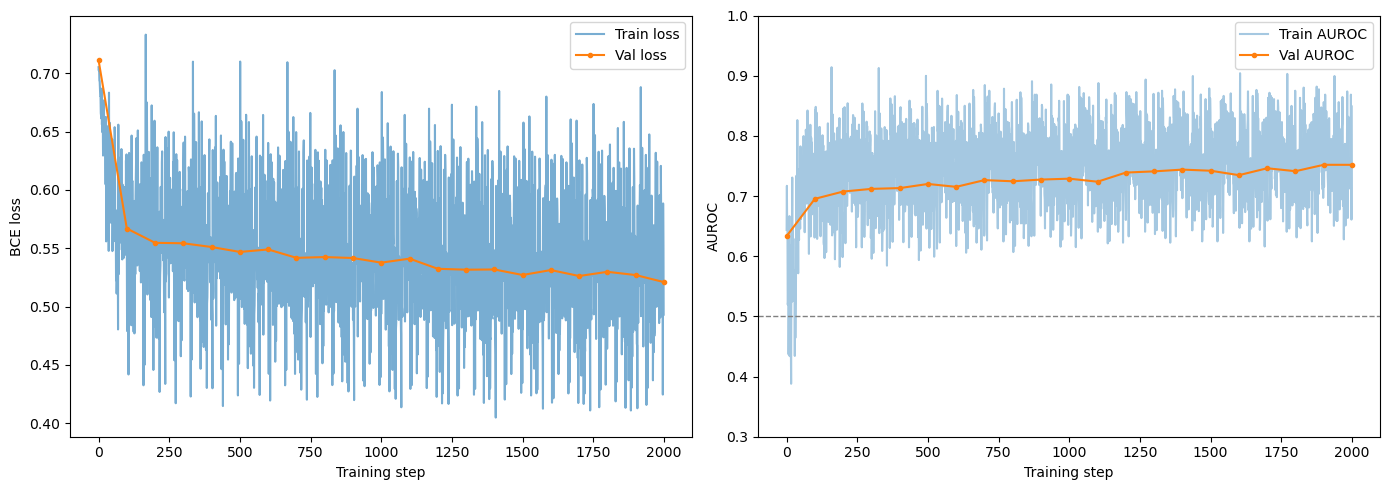

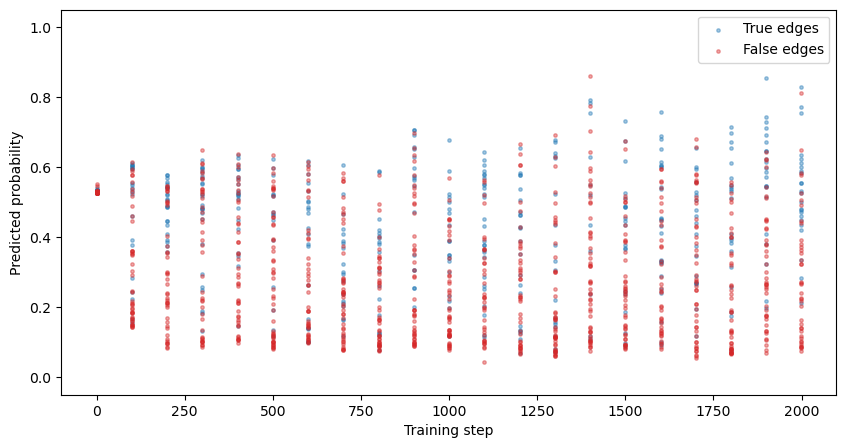

In [ ]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

val = step_df[["Val loss", "Val AUROC"]].dropna()
ax1.plot(step_df.index, step_df["Train loss"], label="Train loss", alpha=0.6)
ax1.plot(val.index, val["Val loss"], label="Val loss", marker="o", ms=3)
ax1.set_xlabel("Training step"); ax1.set_ylabel("BCE loss"); ax1.legend()

ax2.plot(step_df.index, step_df["Train AUROC"], label="Train AUROC", alpha=0.4)
ax2.plot(val.index, val["Val AUROC"], label="Val AUROC", marker="o", ms=3)
ax2.axhline(0.5, color="grey", ls="--", lw=1)
ax2.set_xlabel("Training step"); ax2.set_ylabel("AUROC")
ax2.set_ylim(0.3, 1.0); ax2.legend()

plt.tight_layout(); plt.show()

# Per-edge probabilities from the detail log
plt.figure(figsize=(10, 5))
for label, colour, name in [(1, "tab:blue", "True edges"), (0, "tab:red", "False edges")]:
    subset = edge_df[edge_df["Label"] == label]
    plt.scatter(subset.index, subset["Probability"], c=colour, label=name, alpha=0.4, s=6)
plt.xlabel("Training step"); plt.ylabel("Predicted probability")
plt.ylim(-0.05, 1.05); plt.legend(); plt.show()


### Load WandB Training Logs

In [ ]:
import wandb
api = wandb.Api()

run_id = "brk0jt54"

run = api.run(f"luminarada-penn-state-health/celltype-TF-TG/{run_id}")

# Load the final summary metrics from the run
training_summary = pd.DataFrame.from_dict(run.summary_metrics, orient="index").reset_index().rename(columns={"index": "Metric", 0: "Value"})
display(training_summary)

,Metric,Value
0,_runtime,3.426100e+04
1,_step,9.043900e+04
2,_timestamp,1.789558e+09
3,_wandb.runtime,3.426100e+04
4,epoch,5.400000e+01
5,lr-AdamW,1.250000e-05
6,test/acc,7.598394e-01
7,test/auprc,7.021993e-01
8,test/auroc,8.115445e-01
9,test/celltype/Endothelial/auprc,8.156375e-01


In [ ]:
# Load the run training history
rows = run.scan_history(
    page_size=10_000,
)
run_history = pd.DataFrame(rows)

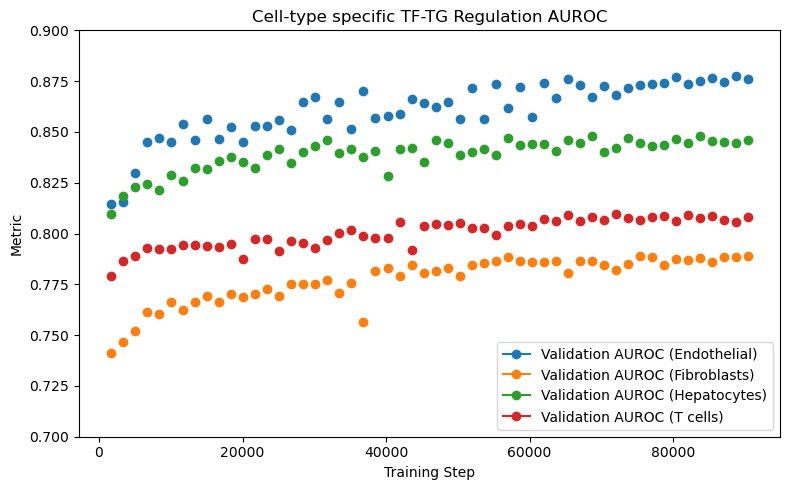

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(figsize=(8, 5))

val_celltypes = run.config["val_celltypes"]
celltype_metric_name_map = {celltype: f"val/celltype/{celltype}/auroc" for celltype in val_celltypes}

for celltype, metric_name in celltype_metric_name_map.items():
    axes.plot(
        run_history["_step"],
        run_history[metric_name],
        marker="o",
        label=f"Validation AUROC ({celltype})",
    )

axes.set_title("Cell-type specific TF-TG Regulation AUROC")
axes.set_xlabel("Training Step")
axes.set_ylabel("Metric")
axes.set_ylim(0.7, 0.9)
axes.legend()

plt.tight_layout()

### Load Trained Model from Checkpoint

In [31]:
import inspect
import models.tf_to_tg_celltype as tf_to_tg_module
import models.tf_to_dna as tf_to_dna_module

def gpu_supports_torch_compile(device):
    if device.type != "cuda":
        return False

    major, minor = torch.cuda.get_device_capability(device)
    return major >= 7

def strip_compiled_prefix_from_state_dict(state_dict, prefix="_orig_mod."):
    """
    Remove torch.compile's _orig_mod prefix from state_dict keys.

    Examples:
        model._orig_mod.encoder.weight -> model.encoder.weight
        _orig_mod.encoder.weight       -> encoder.weight
    """
    cleaned = {}

    for key, value in state_dict.items():
        cleaned_key = key.replace(prefix, "")
        cleaned[cleaned_key] = value

    return cleaned

def load_tf_tg_regulation_model(
    tf_dna_model_path: Path,
    tf_tg_model_path: Path,
    tf_embeddings_tensor: torch.Tensor,
    tf_mask_tensor: torch.Tensor,
    tf_peak_chunk_size: int = 128,
    compile_model: bool = False,
    device: torch.device | None = None,
    model_module=None,
) -> tf_to_tg_module.LitTFTGRegulationModel:
    """
    model_module lets a caller load a checkpoint trained against a different
    TFTGRegulationModel definition than the default models.tf_to_tg -- e.g.
    models.tf_to_tg_testing while it is under active architecture changes there.
    Defaults to models.tf_to_tg (unchanged behaviour for every existing checkpoint).
    """
    model_module = model_module or tf_to_tg_module

    device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")

    if compile_model and not gpu_supports_torch_compile(device):
        if device.type == "cuda":
            major, minor = torch.cuda.get_device_capability(device)
            logging.warning(
                f"Skipping torch.compile because this GPU has compute capability "
                f"{major}.{minor}; Inductor/Triton requires >= 7.0."
            )
        else:
            logging.warning("Skipping torch.compile because device is not CUDA.")

        compile_model = False

    # -----------------------------
    # 1. Recreate base TF-DNA model uncompiled
    # -----------------------------
    base_model = tf_to_dna_module.TFPeakBindingModel(
        tf_embedding_dim=128,
        hidden_dim=128,
        dropout=0.3,
        num_layers=4,
        num_heads=4,
        dim_head=32,
    )

    # -----------------------------
    # 2. Load TF-DNA checkpoint
    # -----------------------------
    tf_dna_ckpt = torch.load(
        tf_dna_model_path,
        map_location="cpu",
        weights_only=False,
    )

    tf_dna_state_dict = tf_dna_ckpt["state_dict"]

    if any("._orig_mod." in key or key.startswith("_orig_mod.") for key in tf_dna_state_dict):
        logging.info("Detected compiled TF-DNA checkpoint. Stripping _orig_mod prefixes.")
        tf_dna_state_dict = strip_compiled_prefix_from_state_dict(tf_dna_state_dict)

    lit_tf_dna_model = tf_to_dna_module.LitTFPeakBindingModel(
        model=base_model,
        tf_embeddings_tensor=tf_embeddings_tensor,
        tf_mask_tensor=tf_mask_tensor,
        lr=1e-4,
        weight_decay=1e-4,
        pos_weight=None,
    )

    lit_tf_dna_model.load_state_dict(tf_dna_state_dict, strict=True)

    trained_tf_peak_model = lit_tf_dna_model.model
    trained_tf_peak_model.eval()

    for p in trained_tf_peak_model.parameters():
        p.requires_grad = False

    # -----------------------------
    # 3. Load TF-TG checkpoint
    # -----------------------------
    tf_tg_ckpt = torch.load(
        tf_tg_model_path,
        map_location="cpu",
        weights_only=False,
    )

    tf_tg_state_dict = tf_tg_ckpt["state_dict"]

    if any("._orig_mod." in key or key.startswith("_orig_mod.") for key in tf_tg_state_dict):
        logging.info("Detected compiled TF-TG checkpoint. Stripping _orig_mod prefixes.")
        tf_tg_state_dict = strip_compiled_prefix_from_state_dict(tf_tg_state_dict)

    lit_tf_tg_model = model_module.LitTFTGRegulationModel(
        lr=1e-4,
        weight_decay=1e-4,
    )

    lit_tf_tg_model.load_state_dict(tf_tg_state_dict, strict=True)
    lit_tf_tg_model.eval()

    for p in lit_tf_tg_model.parameters():
        p.requires_grad = False

    # -----------------------------
    # 5. Optional compile after loading
    # -----------------------------
    if compile_model:
        logging.info("Compiling loaded TF-TG core model.")
        lit_tf_tg_model.model = torch.compile(lit_tf_tg_model.model)

    # Evaluation needs the frozen TF-DNA model to recreate the binding scores.
    return lit_tf_tg_model, trained_tf_peak_model

In [32]:
import wandb

mm10_tf_dna_path = CHKPT_DIR / "new_tf_dna_models" / "mm10_3831017_epoch_12.ckpt"
model_checkpoint = CHKPT_DIR / "celltype_tf_tg" / "celltype_liver_sample_3880373_20260915_180534_132252" / "checkpoints" / "epoch-038.ckpt"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tf_embeddings_tensor = torch.load(tf_embedding_cache_path, weights_only=True)
tf_mask_tensor = torch.load(tf_mask_cache_path, weights_only=True)

trained_model, trained_tf_peak_model = load_tf_tg_regulation_model(
    tf_dna_model_path=mm10_tf_dna_path,
    tf_tg_model_path=model_checkpoint,
    tf_embeddings_tensor= tf_embeddings_tensor,
    tf_mask_tensor= tf_mask_tensor,
    tf_peak_chunk_size=128,
    compile_model=False,
    device=device,
    model_module=tf_to_tg_module,
)

trained_model

LitTFTGRegulationModel(
  (model): SimpleTFTGRegulationModel(
    (peak_feature_proj): Sequential(
      (0): Linear(in_features=4, out_features=128, bias=True)
      (1): SiLU()
      (2): Dropout(p=0.1, inplace=False)
      (3): Linear(in_features=128, out_features=128, bias=True)
    )
    (tf_expr_proj): Sequential(
      (0): Linear(in_features=1, out_features=128, bias=True)
      (1): SiLU()
      (2): Linear(in_features=128, out_features=128, bias=True)
    )
    (tg_expr_proj): Sequential(
      (0): Linear(in_features=1, out_features=128, bias=True)
      (1): SiLU()
      (2): Linear(in_features=128, out_features=128, bias=True)
    )
    (tg_query_proj): Sequential(
      (0): Linear(in_features=128, out_features=128, bias=True)
      (1): SiLU()
      (2): Linear(in_features=128, out_features=128, bias=True)
    )
    (peak_attention): MultiheadAttention(
      (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
    )
    (norm): Layer

### Load Trained Model Data

In [ ]:
def load_model_data(model_checkpoint: Path, trained_tf_peak_model, split_name: str = "test"):
    logging.info(f"Loading model data for checkpoint {model_checkpoint} and split {split_name}")
    from torch.utils.data import DataLoader
    from scripts.train_tf_to_tg_celltype_model import (
        binding_score_cache_path,
        TFTGEdgeBagDataset,
        precompute_binding_scores,
    )
    import hashlib

    def load_run_config(model_checkpoint: Path):
        run_dir = model_checkpoint.parent.parent
        with open(run_dir / "run_config.json") as handle:
            return json.load(handle)

    def load_edge_split_dataset(model_checkpoint: Path, split_name: str = "test"):
        assert split_name in {"train", "val", "test"}, f"Invalid split name: {split_name}"
        run_dir = model_checkpoint.parent.parent
        return pd.read_parquet(run_dir / f"edges_{split_name}.parquet")

    def load_atac_peak_tensor(run_config):
        run_dir = model_checkpoint.parent.parent
        return torch.load(
            run_dir / "prepared" / run_config["sample_name"] / "atac_peak_tensor.pt",
            map_location="cpu", weights_only=True,
        )

    def load_multiome_data(run_config):
        """
        Recreate the RNA and ATAC matrix order. 
        """
        
        eval_data_dir = Path(run_config["data_dir"])
        eval_mdata = mu.read(
            eval_data_dir / "processed" / run_config["tissue"]
            / run_config["sample_name"] / "multiome_processed.h5mu"
        )
        eval_rna = eval_mdata.mod["rna"]
        eval_atac = eval_mdata.mod["atac"]
        shared_cells = eval_rna.obs_names[eval_rna.obs_names.isin(eval_atac.obs_names)]
        eval_rna = eval_rna[shared_cells].copy()
        eval_atac = eval_atac[shared_cells].copy()

        max_autosome = 19 if run_config["species"] == "mm10" else 22
        valid_chroms = {f"chr{i}" for i in range(1, max_autosome + 1)}
        keep_peaks = np.array([
            peak.split(":", 1)[0] in valid_chroms for peak in eval_atac.var_names
        ])
        eval_atac = eval_atac[:, keep_peaks].copy()
        eval_rna.var_names = eval_rna.var_names.str.upper()
        
        return eval_rna, eval_atac

    def get_celltype_dataset_indices(split_df, eval_rna, run_config):
        eval_data_dir = Path(run_config["data_dir"])
        label_map_path = (
            eval_data_dir / "ground_truth_files" / "cell_type_specific"
            / f"{run_config['tissue']}_label_map.tsv"
        )
        if label_map_path.exists():
            label_map = pd.read_csv(label_map_path, sep="\t", comment="#")
            slice_members = label_map.groupby("slice")["paper_celltype"].apply(list).to_dict()
        else:
            slice_members = {name: [name] for name in eval_rna.obs["celltype"].unique()}

        cell_pools = {}
        for slice_name in split_df["cell_type"].unique():
            members = slice_members[slice_name]
            cell_pools[(run_config["sample_name"], slice_name)] = np.flatnonzero(
                eval_rna.obs["celltype"].isin(members).fillna(False).to_numpy()
            )

        return cell_pools

    def check_dataset_indices_match(split_df, eval_rna, atac_mat, atac_peak_tensor):
        # Fail early if the source MuData has changed since training data preparation.
        rna_names = eval_rna.var_names.to_numpy()
        assert np.array_equal(
            rna_names[split_df["tf_rna_col"].to_numpy()], split_df["tf_name"].to_numpy()
        )
        assert np.array_equal(
            rna_names[split_df["tg_rna_col"].to_numpy()], split_df["tg_id"].to_numpy()
        )
        assert atac_mat.shape[1] == atac_peak_tensor.shape[0]

    def load_or_cache_binding_scores(split_df, trained_tf_peak_model, tf_embeddings_tensor, tf_mask_tensor, atac_peak_tensor, run_config, run_dir, device):
        # The TF-TG checkpoint expects precomputed TF-peak binding scores. Cache them
        # with a fingerprint of the exact split row order.
        fingerprint_bytes = pd.util.hash_pandas_object(
            split_df[["cell_type", "tf_name", "tg_id", "label"]], index=False
        ).values.tobytes()
        fingerprint = hashlib.sha1(fingerprint_bytes).hexdigest()[:12]
        legacy_binding_path = (
            run_dir / "prepared"
            / f"{Path(run_config['tf_dna_checkpoint']).stem}__{split_name}"
            f"__P{run_config['max_peaks_per_tg']}__{fingerprint}.pt"
        )
        canonical_binding_path = binding_score_cache_path(
            run_dir / "prepared", split_name, split_df,
            tf_dna_checkpoint=run_config["tf_dna_checkpoint"],
            max_peaks_per_tg=run_config["max_peaks_per_tg"],
        )
        binding_path = (
            canonical_binding_path
            if canonical_binding_path.exists() or not legacy_binding_path.exists()
            else legacy_binding_path
        )
        if binding_path.exists():
            binding_scores = torch.load(
                binding_path, map_location="cpu", weights_only=True
            )
        else:
            trained_tf_peak_model = trained_tf_peak_model.to(device)
            binding_scores = precompute_binding_scores(
                split_df, trained_tf_peak_model,
                tf_embeddings_tensor=tf_embeddings_tensor,
                tf_mask_tensor=tf_mask_tensor,
                atac_peak_tensor=atac_peak_tensor,
                max_peaks_per_tg=run_config["max_peaks_per_tg"],
                device=device, chunk_size=run_config["binding_chunk_size"],
            )
            torch.save(binding_scores, binding_path)

        expected_shape = (len(split_df), run_config["max_peaks_per_tg"])
        if tuple(binding_scores.shape) != expected_shape:
            raise ValueError(
                f"Binding cache has shape {tuple(binding_scores.shape)}; "
                f"expected {expected_shape}. Delete {binding_path} and rerun."
            )
        return binding_scores
    
    logging.info(f"  - Loading config")
    run_config = load_run_config(model_checkpoint)
    logging.info(f"  - Loading edge split dataset")
    split_df = load_edge_split_dataset(model_checkpoint, split_name=split_name)
    logging.info(f"  - Loading ATAC peak tensor")
    atac_peak_tensor = load_atac_peak_tensor(run_config)
    logging.info(f"  - Loading multiome data")
    eval_rna, eval_atac = load_multiome_data(run_config)
    logging.info(f"  - Getting cell type dataset indices")
    cell_pools = get_celltype_dataset_indices(split_df, eval_rna, run_config)

    rna_mat = eval_rna.layers["counts"]
    atac_mat = eval_atac.layers["counts"]

    logging.info(f"  - Checking dataset indices match")
    check_dataset_indices_match(split_df, eval_rna, atac_mat, atac_peak_tensor)

    logging.info(f"  - Loading or caching binding scores")
    split_binding_scores = load_or_cache_binding_scores(
        split_df, trained_tf_peak_model, tf_embeddings_tensor, tf_mask_tensor,
        atac_peak_tensor, run_config, model_checkpoint.parent.parent, device
    )

    logging.info(f"  - Creating dataset and dataloader")
    split_dataset = TFTGEdgeBagDataset(
        split_df,
        tf_embeddings_tensor=None, tf_mask_tensor=None,
        atac_peak_tensor=atac_peak_tensor, atac_mat=atac_mat, rna_mat=rna_mat,
        cell_pools=cell_pools,
        max_peaks_per_tg=run_config["max_peaks_per_tg"],
        resample_max_cells_per_pair=run_config["max_cells_per_pair"],
        resample_cells=False, binding_scores=split_binding_scores,
        seed=run_config["seed"],
    )

    logging.info(f"  - Creating dataloader")
    split_dataloader = DataLoader(
        split_dataset, batch_size=run_config["batch_size"], shuffle=False,
        num_workers=run_config["num_workers"],
        persistent_workers=run_config["num_workers"] > 0,
        pin_memory=device.type == "cuda", drop_last=False,
    )
    
    print(
        f"Loaded {len(split_dataset):,} {split_name} edges "
        f"in {len(split_dataloader):,} batches"
    )
    
    return split_dataset, split_dataloader, run_config

test_dataset, test_dataloader, test_run_config = load_model_data(
    model_checkpoint=model_checkpoint, trained_tf_peak_model=trained_tf_peak_model, split_name="test"
)

INFO:root:Loading model data for checkpoint /gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/TETHER/checkpoints/celltype_tf_tg/celltype_liver_sample_3880373_20260915_180534_132252/checkpoints/epoch-038.ckpt and split test
INFO:root:  - Loading config
INFO:root:  - Loading edge split dataset
INFO:root:  - Loading ATAC peak tensor
INFO:root:  - Loading multiome data
/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1275: FutureWarning: From 0.4 .update() will not pull obs/var c

Loaded 86,667 test edges in 1,355 batches


### Evaluate own test set

In [ ]:
import torch.nn as nn

def run_batch(trained_model, batch_cpu, train: bool, microbatch_size: int = 64):
    """One batch, microbatched. Returns (loss, edge_logits, labels), all on CPU."""
    B = len(batch_cpu["label"])
    
    gpu_keys = [
        "binding_score", "peak_accessibility", "peak_distance",
        "tf_expression", "tg_expression", "cell_mask", "peak_mask", "label",
    ]

    edge_parts, total_loss = [], 0.0
    for start in range(0, B, microbatch_size):
        end = min(start + microbatch_size, B)
        microbatch = {k: batch_cpu[k][start:end].to(device) for k in gpu_keys}

        with torch.set_grad_enabled(train):
            edge_logits, _ = trained_model(microbatch)
            loss = nn.functional.binary_cross_entropy_with_logits(
                edge_logits, microbatch["label"].float(), reduction="sum",
            ) / B

        if train:
            loss.backward()

        total_loss += loss.item()
        edge_parts.append(edge_logits.detach().cpu())
        del microbatch, edge_logits, loss

    return total_loss, torch.cat(edge_parts), batch_cpu["label"].float()

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    logits, labels, loss_sum, n = [], [], 0.0, 0
    for batch_cpu in loader:
        b = len(batch_cpu["label"])
        loss, edge_logits, y = run_batch(model, batch_cpu, train=False)
        loss_sum += loss * b; n += b
        logits.append(edge_logits); labels.append(y)

    logits = torch.cat(logits); labels = torch.cat(labels)
    auroc = (roc_auc_score(labels.numpy(), logits.numpy())
             if labels.min() != labels.max() else float("nan"))
    probabilities = logits.sigmoid()
    avg_loss = loss_sum / n
    
    return avg_loss, auroc, probabilities, labels

trained_model = trained_model.to(device)
eval_loss, eval_auroc, eval_probs, eval_labels = evaluate(trained_model, test_dataloader)


In [51]:
from sklearn.metrics import average_precision_score

def build_performance_dataframe(edge_frame, probabilities, labels):
    """Return edge predictions plus overall, per-cell-type, and macro metrics."""
    probabilities = torch.as_tensor(probabilities).detach().cpu().float().numpy()
    labels = torch.as_tensor(labels).detach().cpu().int().numpy()
    if len(edge_frame) != len(probabilities):
        raise ValueError(
            f"Frame has {len(edge_frame):,} rows but received "
            f"{len(probabilities):,} predictions"
        )
    frame_labels = edge_frame["label"].astype(int).to_numpy()
    if not np.array_equal(frame_labels, labels):
        raise ValueError("Prediction labels are not aligned with the edge-frame rows")

    predictions = edge_frame[[
        "sample_id", "cell_type", "tf_name", "tg_id", "label"
    ]].reset_index(drop=True).copy()
    predictions["probability"] = probabilities
    predictions["predicted_label"] = (probabilities >= 0.5).astype(np.int8)

    def summarize(scope, name, frame):
        y = frame["label"].astype(int).to_numpy()
        p = frame["probability"].to_numpy()
        has_both_labels = np.unique(y).size == 2
        return {
            "scope": scope,
            "cell_type": name,
            "n_edges": len(frame),
            "n_positive": int(y.sum()),
            "positive_fraction": float(y.mean()),
            "loss": float(nn.functional.binary_cross_entropy(
                torch.from_numpy(p).float(), torch.from_numpy(y).float(),
            )),
            "auroc": (
                float(roc_auc_score(y, p)) if has_both_labels else float("nan")
            ),
            "auprc": (
                float(average_precision_score(y, p))
                if has_both_labels else float("nan")
            ),
            "accuracy": float(((p >= 0.5).astype(int) == y).mean()),
        }

    rows = [summarize("overall", "all", predictions)]
    rows.extend(
        summarize("cell_type", cell_type, frame)
        for cell_type, frame in predictions.groupby("cell_type", sort=True)
    )
    performance = pd.DataFrame(rows)
    per_cell_type = performance[performance["scope"] == "cell_type"]
    macro = {
        "scope": "macro_cell_type",
        "cell_type": "mean",
        "n_edges": int(per_cell_type["n_edges"].sum()),
        "n_positive": int(per_cell_type["n_positive"].sum()),
    }
    for column in ["positive_fraction", "loss", "auroc", "auprc", "accuracy"]:
        macro[column] = float(per_cell_type[column].mean())
    performance = pd.concat(
        [performance, pd.DataFrame([macro])], ignore_index=True
    )
    return predictions, performance

test_predictions, test_performance_df = build_performance_dataframe(
    test_dataset.inputs, eval_probs, eval_labels
)
test_predictions.to_parquet(
    model_checkpoint.parent.parent / "test_predictions.parquet", index=False
)
test_performance_df.to_csv(
    model_checkpoint.parent.parent / "test_performance_by_celltype.csv", index=False
)
print(f"Evaluation results on test set: Loss = {eval_loss:.4f}, AUROC = {eval_auroc:.4f}")
display(test_performance_df.round(4))

Evaluation results on test set: Loss = 0.4927, AUROC = 0.8115


,scope,cell_type,n_edges,n_positive,positive_fraction,loss,auroc,auprc,accuracy
0,overall,all,86667,29645,0.3421,0.4927,0.8115,0.7022,0.7598
1,cell_type,Endothelial,4704,1795,0.3816,0.4361,0.8869,0.8156,0.8031
2,cell_type,Fibroblasts,17550,6379,0.3635,0.5397,0.7860,0.6579,0.7157
3,cell_type,Hepatocytes,19320,6440,0.3333,0.4654,0.8392,0.7370,0.7795
4,cell_type,T cells,45093,15031,0.3333,0.4920,0.8069,0.6956,0.7641
5,macro_cell_type,mean,86667,29645,0.3529,0.4833,0.8298,0.7265,0.7656


### External evaluation: mESC E7.5_rep1

Build an mESC chromosome-held-out test set with the liver model's data settings. The output is isolated under the liver run's `external_evaluation` directory, so it cannot overwrite the original liver splits.

In [49]:
from types import SimpleNamespace
from torch.utils.data import DataLoader
from scripts.train_tf_to_tg_celltype_model import (
    TFTGEdgeBagDataset,
    load_or_precompute_binding_scores,
    prepare_data,
)

# Keep the liver training data settings, but build features and labels from
# the mESC E7.5_rep1 MuData and cell-type-specific ground truths.
mesc_eval_dir = (
    model_checkpoint.parent.parent / "external_evaluation" / "mESC_E7.5_rep1"
)
mesc_eval_dir.mkdir(parents=True, exist_ok=True)

mesc_args = SimpleNamespace(
    species="mm10",
    tissue="mESC",
    sample_name="E7.5_rep1",
    data_dir=Path(test_run_config["data_dir"]),
    gene_ref_file=None,
    output_dir=mesc_eval_dir,
    num_workers=test_run_config["num_workers"],
    max_cells_per_pair=test_run_config["max_cells_per_pair"],
    max_peaks_per_tg=test_run_config["max_peaks_per_tg"],
    peak_flank_size=test_run_config["peak_flank_size"],
    true_false_ratio=test_run_config["true_false_ratio"],
    balance_tf=test_run_config["balance_tf"],
    balance_tg=test_run_config["balance_tg"],
    min_cells_per_slice=test_run_config["min_cells_per_slice"],
    min_tfs_per_slice=test_run_config["min_tfs_per_slice"],
    max_gt_density=test_run_config["max_gt_density"],
    seed=test_run_config["seed"],
)

(
    mesc_splits, mesc_cell_pools, mesc_atac_mat, mesc_rna_mat,
    mesc_peak_tensor, mesc_embedding_path, mesc_mask_path,
) = prepare_data(mesc_args)
if "test" not in mesc_splits or mesc_splits["test"].empty:
    raise ValueError("No eligible mESC E7.5_rep1 edges were created for test chromosomes")

mesc_test_frame = mesc_splits["test"]
trained_tf_peak_model = trained_tf_peak_model.to(device)
mesc_binding_scores, mesc_binding_cache = load_or_precompute_binding_scores(
    "test",
    mesc_test_frame,
    trained_tf_peak_model,
    prepared_dir=mesc_eval_dir / "prepared",
    tf_dna_checkpoint=mm10_tf_dna_path,
    tf_embeddings_tensor=tf_embeddings_tensor,
    tf_mask_tensor=tf_mask_tensor,
    atac_peak_tensor=mesc_peak_tensor,
    max_peaks_per_tg=mesc_args.max_peaks_per_tg,
    device=device,
    chunk_size=test_run_config["binding_chunk_size"],
)

mesc_test_dataset = TFTGEdgeBagDataset(
    mesc_test_frame,
    tf_embeddings_tensor=None,
    tf_mask_tensor=None,
    atac_peak_tensor=mesc_peak_tensor,
    atac_mat=mesc_atac_mat,
    rna_mat=mesc_rna_mat,
    cell_pools=mesc_cell_pools,
    max_peaks_per_tg=mesc_args.max_peaks_per_tg,
    resample_max_cells_per_pair=mesc_args.max_cells_per_pair,
    resample_cells=False,
    binding_scores=mesc_binding_scores,
    seed=mesc_args.seed,
)
mesc_test_dataloader = DataLoader(
    mesc_test_dataset,
    batch_size=test_run_config["batch_size"],
    shuffle=False,
    num_workers=test_run_config["num_workers"],
    persistent_workers=test_run_config["num_workers"] > 0,
    pin_memory=device.type == "cuda",
    drop_last=False,
)

mesc_build_config = {
    key: str(value) if isinstance(value, Path) else value
    for key, value in vars(mesc_args).items()
}
mesc_build_config["binding_cache"] = str(mesc_binding_cache)
(mesc_eval_dir / "evaluation_config.json").write_text(
    json.dumps(mesc_build_config, indent=2)
)
print(
    f"Built {len(mesc_test_dataset):,} mESC test edges across "
    f"{mesc_test_frame['cell_type'].nunique():,} cell-type slices; "
    f"{len(mesc_test_dataloader):,} batches"
)

INFO:root:Splitting genes into train/val/test based on chromosome:
INFO:root:Extracted GTF attributes: ['gene_id', 'gene_version', 'gene_name', 'gene_source', 'gene_biotype', 'transcript_id', 'transcript_version', 'transcript_name', 'transcript_source', 'transcript_biotype', 'tag', 'transcript_support_level', 'exon_number', 'exon_id', 'exon_version', 'protein_id', 'protein_version', 'ccds_id']
INFO:root:  - Train set: 62,426 genes (chroms 1-15)
INFO:root:  - Validation set: 5,700 genes (chroms 16-17)
INFO:root:  - Test set: 4,099 genes (chroms 18-19)
INFO:root: Building for Sample: E7.5_rep1, Tissue: mESC

/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexib

RNA: (6832, 2608)
ATAC: (6832, 15888)
Sequence peaks: 15888
Annotated cell types: 36


INFO:root:Creating centered peak one-hot encodings for ATAC peaks...


                         slice  cells  types  edges  TFs  TGs  density           use
          ExE_endoderm_lineage   1411      3    128    1  128    1.000   too few TFs
                  ExE_ectoderm   1190      1  14315   16 2183    0.410           yes
              Mesoderm_lineage   1084      8   2727    3 1648    0.552   too few TFs
              Epiblast_lineage    887      4   8690   10 2298    0.378           yes
                  Neurectoderm    592      2  11841   16 2164    0.342           yes
                    Mesenchyme    515      1  10457   13 2145    0.375           yes
              Surface_ectoderm    238      1   4130    7 1693    0.348           yes
                           Gut    207      1   1110    2  987    0.562   too few TFs
Haematoendothelial_progenitors    161      1   1218    1 1218    1.000   too few TFs
             Blood_progenitors    159      2  11370   14 2061    0.394           yes
           Definitive_endoderm    134      1   1318    2 1080    

One-hot peaks:   0%|                                  | 0/15888 [00:00<?, ?it/s]

INFO:root:Blood_progenitors: 159 cells from 2 annotated types, 11,370 GT edges, 14 TFs
INFO:root:Epiblast_lineage: 887 cells from 4 annotated types, 8,690 GT edges, 10 TFs
INFO:root:ExE_ectoderm: 1,190 cells from 1 annotated types, 14,315 GT edges, 16 TFs
INFO:root:Mesenchyme: 515 cells from 1 annotated types, 10,457 GT edges, 13 TFs
INFO:root:Neurectoderm: 592 cells from 2 annotated types, 11,841 GT edges, 16 TFs
INFO:root:Surface_ectoderm: 238 cells from 1 annotated types, 4,130 GT edges, 7 TFs
Binding scores: 100%|█████████████████████████| 221/221 [00:26<00:00,  8.23it/s]
INFO:root:test: cached binding scores (11092, 25) at /gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/TETHER/checkpoints/celltype_tf_tg/celltype_liver_sample_3880373_20260915_180534_132252/external_evaluation/mESC_E7.5_rep1/prepared/binding_scores_test_6770328b61392448.pt


28,276 distinct (TF, peak) pairs for 42,807 slots across 11,092 edges (1.1 MB)
Built 11,092 mESC test edges across 6 cell-type slices; 174 batches


In [50]:
from sklearn.metrics import average_precision_score

mesc_eval_loss, mesc_eval_auroc, mesc_probs, mesc_labels = evaluate(
    trained_model, mesc_test_dataloader
)
mesc_predictions = mesc_test_frame[[
    "sample_id", "cell_type", "tf_name", "tg_id", "label"
]].copy()
mesc_predictions["probability"] = mesc_probs.numpy()
mesc_predictions["predicted_label"] = (
    mesc_predictions["probability"] >= 0.5
).astype(np.int8)

def summarize_prediction_group(scope, name, frame):
    labels = frame["label"].astype(int).to_numpy()
    probabilities = frame["probability"].to_numpy()
    has_both_labels = np.unique(labels).size == 2
    return {
        "scope": scope,
        "cell_type": name,
        "n_edges": len(frame),
        "n_positive": int(labels.sum()),
        "positive_fraction": float(labels.mean()),
        "loss": float(nn.functional.binary_cross_entropy(
            torch.from_numpy(probabilities).float(),
            torch.from_numpy(labels).float(),
        )),
        "auroc": (
            float(roc_auc_score(labels, probabilities))
            if has_both_labels else float("nan")
        ),
        "auprc": (
            float(average_precision_score(labels, probabilities))
            if has_both_labels else float("nan")
        ),
        "accuracy": float(
            ((probabilities >= 0.5).astype(int) == labels).mean()
        ),
    }

metric_rows = [summarize_prediction_group(
    "overall", "all", mesc_predictions
)]
metric_rows.extend(
    summarize_prediction_group("cell_type", cell_type, frame)
    for cell_type, frame in mesc_predictions.groupby("cell_type", sort=True)
)
mesc_metrics = pd.DataFrame(metric_rows)
cell_type_metrics = mesc_metrics[mesc_metrics["scope"] == "cell_type"]
macro_row = pd.DataFrame([{
    "scope": "macro_cell_type",
    "cell_type": "mean",
    "n_edges": int(cell_type_metrics["n_edges"].sum()),
    "n_positive": int(cell_type_metrics["n_positive"].sum()),
    "positive_fraction": float(cell_type_metrics["positive_fraction"].mean()),
    "loss": float(cell_type_metrics["loss"].mean()),
    "auroc": float(cell_type_metrics["auroc"].mean()),
    "auprc": float(cell_type_metrics["auprc"].mean()),
    "accuracy": float(cell_type_metrics["accuracy"].mean()),
}])
mesc_metrics = pd.concat([mesc_metrics, macro_row], ignore_index=True)

mesc_predictions.to_parquet(
    mesc_eval_dir / "test_predictions.parquet", index=False
)
mesc_metrics.to_csv(mesc_eval_dir / "test_metrics.csv", index=False)
print(f"mESC E7.5_rep1 overall loss: {mesc_eval_loss:.4f}")
display(mesc_metrics.round(4))

mESC E7.5_rep1 overall loss: 0.8450


,scope,cell_type,n_edges,n_positive,positive_fraction,loss,auroc,auprc,accuracy
0,overall,all,11092,4373,0.3942,0.8450,0.6292,0.5204,0.6265
1,cell_type,Blood_progenitors,2030,822,0.4049,0.9539,0.4823,0.4347,0.5906
2,cell_type,Epiblast_lineage,1590,620,0.3899,0.7460,0.6836,0.5890,0.6566
3,cell_type,ExE_ectoderm,2400,1016,0.4233,0.7691,0.7105,0.6201,0.6175
4,cell_type,Mesenchyme,1898,761,0.4009,0.8487,0.6560,0.5391,0.6154
5,cell_type,Neurectoderm,2320,837,0.3608,0.9276,0.5943,0.4539,0.6466
6,cell_type,Surface_ectoderm,854,317,0.3712,0.7513,0.6588,0.5320,0.6511
7,macro_cell_type,mean,11092,4373,0.3919,0.8328,0.6309,0.5281,0.6296
